# **Project Name**    - FBI Crime Investigation & Monthly Crime Prediction



##### **Project Type**    - Regression
##### **Contribution**    - Individual

# **Project Summary -**

## Project Summary

I developed an individual machine learning project focused on analyzing **historical crime patterns and forecasting monthly crime incidents** using the FBI Crime Investigation dataset. The objective was to identify temporal and geographical patterns in crime data and develop a data-driven approach to monthly crime-volume prediction.

I began by performing data preprocessing, including handling missing values, removing duplicate records, standardizing date-related features, and examining numerical and categorical variables. I also applied categorical encoding and frequency encoding to prepare relevant features for analysis and machine learning.

I conducted exploratory data analysis (EDA) to investigate crime trends across years, months, hours, crime types, and neighbourhoods. I used visualizations such as **line charts, bar charts, heatmaps, box plots, scatter plots, and Pareto analysis** to identify patterns in crime distribution and temporal behaviour.

To validate statistical relationships, I performed hypothesis testing using the **Mann–Whitney U test and Chi-square test** of independence. The results indicated statistically significant differences in selected crime-volume groups and an association between crime type and time of day.

For monthly crime prediction, I evaluated multiple machine learning and time-series approaches, including **Linear Regression, Random Forest, Gradient Boosting, Seasonal Naive, and SARIMA**. I also engineered lag and rolling-average features to capture historical crime patterns and seasonal behaviour.

I implemented **chronological walk-forward validation to evaluate one-step-ahead forecasting performance without randomly shuffling the time-series data**. Among the evaluated walk-forward models, XGBoost achieved a Mean Absolute Error (MAE) of 165.69, Root Mean Squared Error (RMSE) of 218.64, and R² score of 0.4916.

To improve model interpretability, I used **SHAP analysis** to understand feature contributions. **Lag_12 and Rolling_Mean_12** were the most influential features, highlighting the importance of annual historical patterns and longer-term crime trends.

The project demonstrates my practical understanding of data preprocessing, exploratory analysis, statistical testing, feature engineering, machine learning, time-series validation, and model explainability. However, the forecasting results require further validation and improvement before the model can be considered suitable for operational decision-making.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Crime does not occur randomly; it follows patterns across time, location, and crime type. However, when thousands of individual incidents are recorded at the day and hour level, these patterns can be difficult to translate into a clear view of how crime activity may evolve over time. This creates a practical challenge for law enforcement agencies that need to plan patrol coverage, allocate personnel, and prioritize public-safety resources ahead of changing crime conditions.

This project addresses that challenge by using historical crime records, including timestamps, crime categories, geographical coordinates, and neighborhood information, to identify temporal and spatial patterns and develop a machine learning model for predicting monthly crime incident volumes. The objective is not simply to forecast a number; it is to turn detailed historical incident data into an actionable view of expected crime activity that can support more informed, proactive resource planning.

# **Business Objective**



The objective of this project is to transform historical crime records into forward-looking insights that can support proactive public-safety planning. By analyzing when, where, and which types of crimes occur, the project aims to identify recurring temporal and spatial patterns and predict monthly crime incident volumes. These insights can help law enforcement agencies anticipate periods of higher crime activity, plan patrol coverage, allocate personnel more effectively, and prioritize resources across locations. The analysis can also provide urban planners and public-safety stakeholders with evidence to support longer-term decisions around community safety and preventive measures.

## ***1. Know Your Data***

### Import Libraries

In [93]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [94]:
# Load Dataset
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [95]:
# Load Train and Test datasets from Google Drive

train_path = '/content/drive/MyDrive/Train.xlsx - Train.csv'
test_path = '/content/drive/MyDrive/Test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

### Dataset First View

In [96]:
# Dataset First Look
# Display the first 5 records of the training dataset
train_df.head()

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
0,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,12/5/1999
1,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,7/5/1999
2,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,23/4/1999
3,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,20/4/1999
4,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,12/4/1999


### Dataset Rows & Columns count

In [97]:
# Check number of rows and columns

print("Number of Rows:", train_df.shape[0])
print("Number of Columns:", train_df.shape[1])

Number of Rows: 474565
Number of Columns: 13


### Dataset Information

In [98]:
# Dataset information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474565 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TYPE           474565 non-null  object 
 1   HUNDRED_BLOCK  474552 non-null  object 
 2   NEIGHBOURHOOD  423074 non-null  object 
 3   X              474565 non-null  float64
 4   Y              474565 non-null  float64
 5   Latitude       474565 non-null  float64
 6   Longitude      474565 non-null  float64
 7   HOUR           425200 non-null  float64
 8   MINUTE         425200 non-null  float64
 9   YEAR           474565 non-null  int64  
 10  MONTH          474565 non-null  int64  
 11  DAY            474565 non-null  int64  
 12  Date           474565 non-null  object 
dtypes: float64(6), int64(3), object(4)
memory usage: 47.1+ MB


#### Duplicate Values

In [99]:
# Dataset Duplicate Value Count
print("Duplicate rows:", train_df.duplicated().sum())

Duplicate rows: 44618


#### Missing Values/Null Values

In [100]:
# Missing Values/Null Values Count
missing_values = train_df.isnull().sum()

print(missing_values[missing_values > 0])

HUNDRED_BLOCK       13
NEIGHBOURHOOD    51491
HOUR             49365
MINUTE           49365
dtype: int64


### What did you know about your dataset?

The dataset contains 474,565 crime records with 13 variables covering crime type, location, neighbourhood, geographical coordinates, time, and date-related information. The dataset contains both numerical and categorical variables and includes missing values in HUNDRED_BLOCK, NEIGHBOURHOOD, HOUR, and MINUTE. A total of 44,618 duplicate records were identified and will be investigated before deciding on their treatment. The dataset provides both temporal and spatial information that can be used to identify crime patterns and develop a monthly crime prediction model.

## ***2. Understanding Your Variables***

In [101]:
# Dataset Columns
train_df.columns

Index(['TYPE', 'HUNDRED_BLOCK', 'NEIGHBOURHOOD', 'X', 'Y', 'Latitude',
       'Longitude', 'HOUR', 'MINUTE', 'YEAR', 'MONTH', 'DAY', 'Date'],
      dtype='object')

#### Statistical Summary

1. Numerical variables

In [102]:
# Statistical summary of numerical variables
train_df.describe()

,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY
count,474565.000000,4.745650e+05,474565.000000,474565.000000,425200.000000,425200.000000,474565.000000,474565.000000,474565.000000
mean,441028.018220,4.889023e+06,44.138029,-110.301025,13.721263,16.736047,2004.363632,6.555700,15.439253
std,150295.319332,1.665850e+06,15.039271,37.583147,6.785751,18.354675,3.850689,3.408676,8.759352
min,0.000000,0.000000e+00,0.000000,-124.549757,0.000000,0.000000,1999.000000,1.000000,1.000000
25%,489916.530000,5.453572e+06,49.234871,-123.127383,9.000000,0.000000,2001.000000,4.000000,8.000000
50%,491477.850000,5.456820e+06,49.264051,-123.107058,15.000000,10.000000,2004.000000,7.000000,15.000000
75%,493610.190000,5.458622e+06,49.280300,-123.065646,19.000000,30.000000,2008.000000,9.000000,23.000000
max,511303.000000,5.512579e+06,49.755314,0.000000,23.000000,59.000000,2011.000000,12.000000,31.000000


2. Categorical variables

In [103]:
# Statistical summary of categorical variables
train_df.describe(include='object')

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,Date
count,474565,474552,423074,474565
unique,9,20566,24,4748
top,Theft from Vehicle,OFFSET TO PROTECT PRIVACY,Central Business District,15/6/2007
freq,153932,49365,96171,649


### Variables Description

| Variable        | Description                                          |
| --------------- | ---------------------------------------------------- |
| `TYPE`          | Type/category of crime reported                      |
| `HUNDRED_BLOCK` | Approximate street block where the incident occurred |
| `NEIGHBOURHOOD` | Neighbourhood associated with the incident           |
| `X`             | X-coordinate representing the incident location      |
| `Y`             | Y-coordinate representing the incident location      |
| `Latitude`      | Latitude of the incident location                    |
| `Longitude`     | Longitude of the incident location                   |
| `HOUR`          | Hour of the reported incident                        |
| `MINUTE`        | Minute of the reported incident                      |
| `YEAR`          | Year of the incident                                 |
| `MONTH`         | Month of the incident                                |
| `DAY`           | Day of the incident                                  |
| `Date`          | Date associated with the incident                    |


### Check Unique Values for each variable.

In [104]:
# Check unique values for each variable

for column in train_df.columns:
    print(f"\n{column}:")
    print("Number of unique values:", train_df[column].nunique())


TYPE:
Number of unique values: 9

HUNDRED_BLOCK:
Number of unique values: 20566

NEIGHBOURHOOD:
Number of unique values: 24

X:
Number of unique values: 84225

Y:
Number of unique values: 82768

Latitude:
Number of unique values: 89488

Longitude:
Number of unique values: 87190

HOUR:
Number of unique values: 24

MINUTE:
Number of unique values: 60

YEAR:
Number of unique values: 13

MONTH:
Number of unique values: 12

DAY:
Number of unique values: 31

Date:
Number of unique values: 4748


## 3. ***Data Wrangling***

### Data Wrangling Code

In [105]:
# ============================================================
# DATA WRANGLING
# ============================================================

# ------------------------------------------------------------
# 1. Create a working copy of the raw dataset
# ------------------------------------------------------------
df = train_df.copy()

print("Initial shape:", df.shape)


# ------------------------------------------------------------
# 2. Handle Duplicate Records
# ------------------------------------------------------------

# Check the number of exact duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate records found:", duplicate_count)

# Remove exact duplicate records
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)


# ------------------------------------------------------------
# 3. Handle Missing Values
# ------------------------------------------------------------

# Check missing values before treatment
print("\nMissing values before treatment:")
print(df.isnull().sum())


# HUNDRED_BLOCK:
# This column contains location/block information.
# Missing values are replaced with 'Unknown' to retain the records.
df['HUNDRED_BLOCK'] = df['HUNDRED_BLOCK'].fillna('Unknown')


# NEIGHBOURHOOD:
# Missing neighbourhood information is retained as 'Unknown'
# rather than dropping a large number of crime records.
df['NEIGHBOURHOOD'] = df['NEIGHBOURHOOD'].fillna('Unknown')


# HOUR and MINUTE:
# Missing time information cannot be reliably inferred from
# other columns, so we retain the missing information using
# a separate placeholder value.
df['HOUR'] = df['HOUR'].fillna(-1)
df['MINUTE'] = df['MINUTE'].fillna(-1)


# ------------------------------------------------------------
# 4. Check Missing Values After Treatment
# ------------------------------------------------------------

print("\nMissing values after treatment:")
print(df.isnull().sum())

# 5. Standardize Date Column
df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True,
    errors='coerce'
)

print("\nInvalid Date values after conversion:",
      df['Date'].isna().sum())


# ------------------------------------------------------------
# 6. Check Data Consistency
# ------------------------------------------------------------

# Check whether YEAR, MONTH and DAY contain valid ranges
print("\nYEAR range:", df['YEAR'].min(), "to", df['YEAR'].max())
print("MONTH range:", df['MONTH'].min(), "to", df['MONTH'].max())
print("DAY range:", df['DAY'].min(), "to", df['DAY'].max())


# Check time ranges excluding our -1 missing-value placeholder
print("\nHOUR range:", df.loc[df['HOUR'] >= 0, 'HOUR'].min(),
      "to", df.loc[df['HOUR'] >= 0, 'HOUR'].max())

print("MINUTE range:", df.loc[df['MINUTE'] >= 0, 'MINUTE'].min(),
      "to", df.loc[df['MINUTE'] >= 0, 'MINUTE'].max())


# ------------------------------------------------------------
# 7. Check for Invalid Geographic Values
# ------------------------------------------------------------

print("\nInvalid Latitude values:",
      ((df['Latitude'] < -90) | (df['Latitude'] > 90)).sum())

print("Invalid Longitude values:",
      ((df['Longitude'] < -180) | (df['Longitude'] > 180)).sum())


# ------------------------------------------------------------
# 8. Final Dataset Shape After Wrangling
# ------------------------------------------------------------

print("\nFinal shape after data wrangling:", df.shape)

Initial shape: (474565, 13)
Duplicate records found: 44618
Shape after removing duplicates: (429947, 13)

Missing values before treatment:
TYPE                0
HUNDRED_BLOCK      13
NEIGHBOURHOOD    6873
X                   0
Y                   0
Latitude            0
Longitude           0
HOUR             4747
MINUTE           4747
YEAR                0
MONTH               0
DAY                 0
Date                0
dtype: int64

Missing values after treatment:
TYPE             0
HUNDRED_BLOCK    0
NEIGHBOURHOOD    0
X                0
Y                0
Latitude         0
Longitude        0
HOUR             0
MINUTE           0
YEAR             0
MONTH            0
DAY              0
Date             0
dtype: int64

Invalid Date values after conversion: 0

YEAR range: 1999 to 2011
MONTH range: 1 to 12
DAY range: 1 to 31

HOUR range: 0.0 to 23.0
MINUTE range: 0.0 to 59.0

Invalid Latitude values: 0
Invalid Longitude values: 0

Final shape after data wrangling: (429947, 13)


### What all manipulations have you done and insights you found?

- Removed 44,618 exact duplicate records, reducing the dataset from 474,565 to 429,947 records.
- Handled missing values by replacing missing HUNDRED_BLOCK and NEIGHBOURHOOD with "Unknown". Missing HOUR and MINUTE values were represented using -1 as a placeholder and excluded from time-based analysis when valid hours were required.
- Validated temporal variables and found YEAR ranging from 1999–2011, MONTH from 1–12, DAY from 1–31, HOUR from 0–23, and MINUTE from 0–59.
- Checked geographic coordinates and found no invalid Latitude or Longitude values.
- After wrangling, the dataset contains 429,947 records and 13 columns with no remaining missing values.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Yearly Crime Trends for Top 5 Crime Types - Line Chart

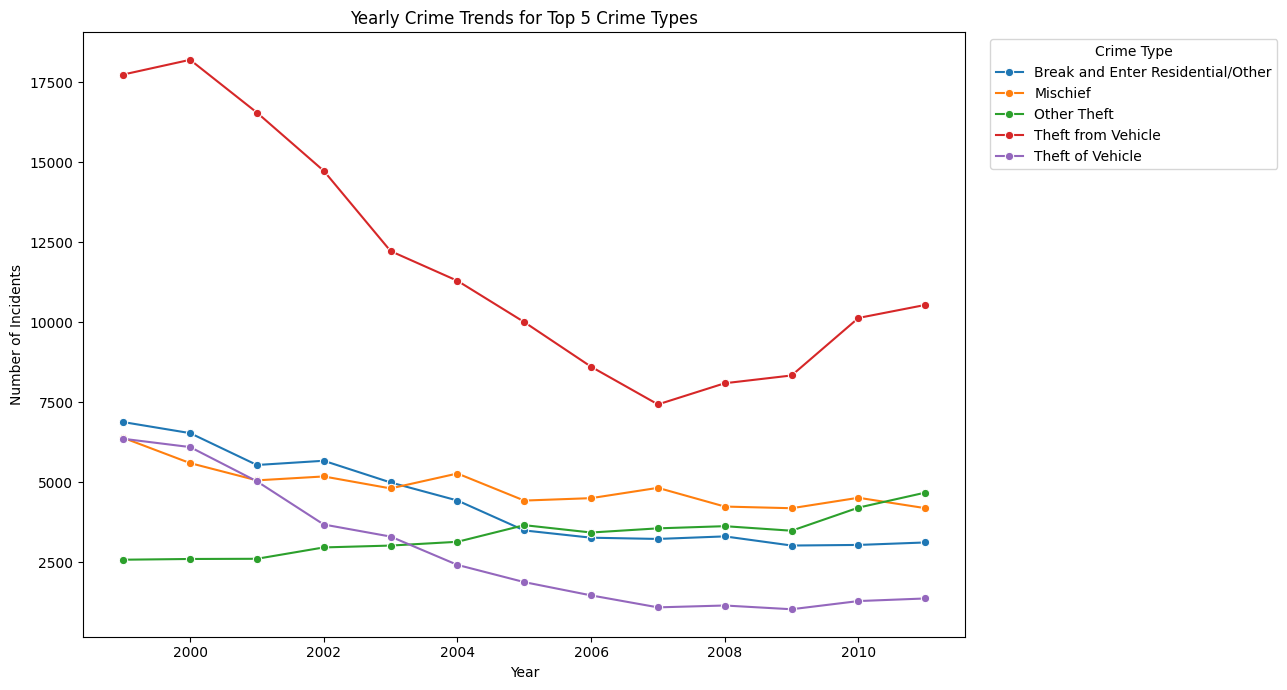

In [106]:
# Bivariate Analysis: Analyze yearly trends across the top crime types

top_crimes = df['TYPE'].value_counts().head(5).index

# Filter data for the top 5 crime types
crime_yearly = (
    df[df['TYPE'].isin(top_crimes)]
    .groupby(['YEAR', 'TYPE'])
    .size()
    .reset_index(name='Incidents')
)

# Create the line chart
plt.figure(figsize=(13, 7))

sns.lineplot(
    data=crime_yearly,
    x='YEAR',
    y='Incidents',
    hue='TYPE',
    marker='o'
)

# Add chart title and axis labels
plt.title('Yearly Crime Trends for Top 5 Crime Types')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')

# Display the chart neatly
plt.legend(title='Crime Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **multi-line chart** compares how the major crime categories changed over the same years and shows whether the overall trend is driven by specific crime types.

##### 2. What is/are the insight(s) found from the chart?

- **Theft from Vehicle dominates throughout**, falling from ~18K in 1999 to ~7.4K in 2007, then recovering to ~10.5K by 2011.
- **Theft of Vehicle shows the sharpest sustained decline**, dropping from ~6.3K in 1999 to ~1.0K in 2007, with only a modest recovery afterward.
- **Other Theft moves in the opposite direction**, rising from ~2.6K to ~4.7K by 2011, making it the only top category with a clear long-term increase.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes**. The different trajectories show that crime categories should not be treated uniformly; patrol and prevention strategies can be aligned with the categories showing higher or recovering volumes.

**Negative growth:** Theft from Vehicle and Theft of Vehicle experienced substantial declines before 2007, while Other Theft increased over the period. This suggests the overall trend is **category-specific rather than uniform across crime types**.

#### Chart 2: Yearly Crime Incident Trend - Line Chart

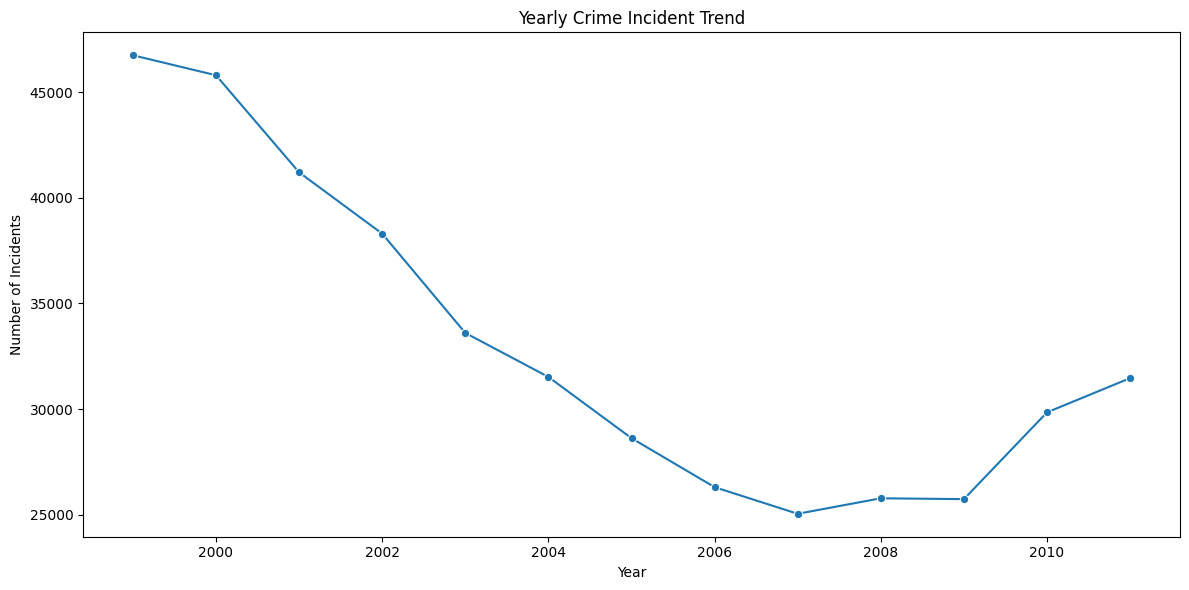

In [107]:
# Univariate Analysis: Analyze the overall yearly trend in crime incidents

# Count the number of recorded crime incidents for each year
yearly_crime = df['YEAR'].value_counts().sort_index()

# Create the line chart to show the yearly trend
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=yearly_crime.index,
    y=yearly_crime.values,
    marker='o'
)

# Add chart title and axis labels
plt.title('Yearly Crime Incident Trend')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')

# Display the chart neatly
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **line chart** is suitable for showing how crime incident volume changes over time and identifying long-term trends.

##### 2. What is/are the insight(s) found from the chart?

- Crime incidents **declined from approximately 46.7K in 1999 to 25K in 2007**, a decrease of about 46%.
- **Incidents then increased to approximately 31.5K by 2011**, indicating a notable recovery after 2007.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes**. Identifying periods of decline and recovery can support long-term patrol planning, resource allocation, and forecasting future crime volumes.

Crime incidents increased after 2007, indicating a recovery in recorded incident volume. This chart shows **changes over time but does not establish the reasons behind the increase**.

#### Chart 3: Monthly Crime Incident Trend - Line Chart

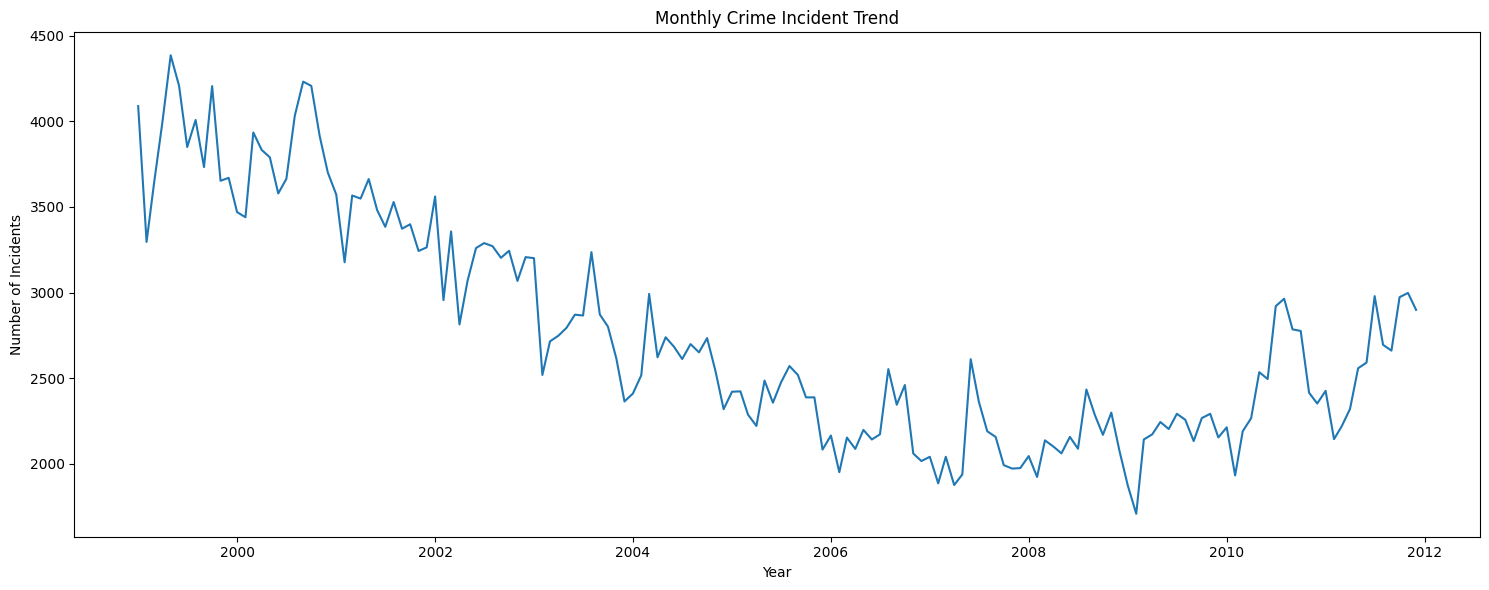

In [108]:
# Bivariate Analysis: Analyze month-to-month crime incident trends over time

# Create a continuous Year-Month period
monthly_trend = (
    df.groupby(['YEAR', 'MONTH'])
      .size()
      .reset_index(name='Incidents')
)

# Create a proper time index for plotting
monthly_trend['Year_Month'] = pd.to_datetime(
    monthly_trend['YEAR'].astype(str) + '-' +
    monthly_trend['MONTH'].astype(str) + '-01'
)

# Sort chronologically
monthly_trend = monthly_trend.sort_values('Year_Month')

# Create the line chart
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=monthly_trend,
    x='Year_Month',
    y='Incidents'
)

# Add title and labels
plt.title('Monthly Crime Incident Trend')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **line chart** is appropriate because it captures month-to-month movement and reveals both the **long-term trend** and **short-term fluctuations** relevant to monthly crime prediction.

##### 2. What is/are the insight(s) found from the chart?

- Monthly incidents show a clear **downward trend from ~4.4K at the early-period peak to mostly ~2.0–2.5K during 2006–2010**, indicating a substantial reduction in monthly crime volume.
- The series becomes more volatile after 2006, with several sharp spikes and dips rather than a smooth trend.
- From **2010 onward, monthly volume rises again**, reaching around **3.0K by late 2011**, consistent with the recovery observed in the annual trend.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes**. The month-level fluctuations show why annual averages alone are insufficient; forecasting should account for **temporal trends and short-term variation** when planning resources.

**Negative growth:** The prolonged decline through roughly 2007–2009 represents lower incident volume, while the subsequent rise from 2010 indicates a **reversal in the monthly trend** that warrants further investigation.

#### Chart 4: Distribution of Monthly Crime Incidents by Year - Box Plot

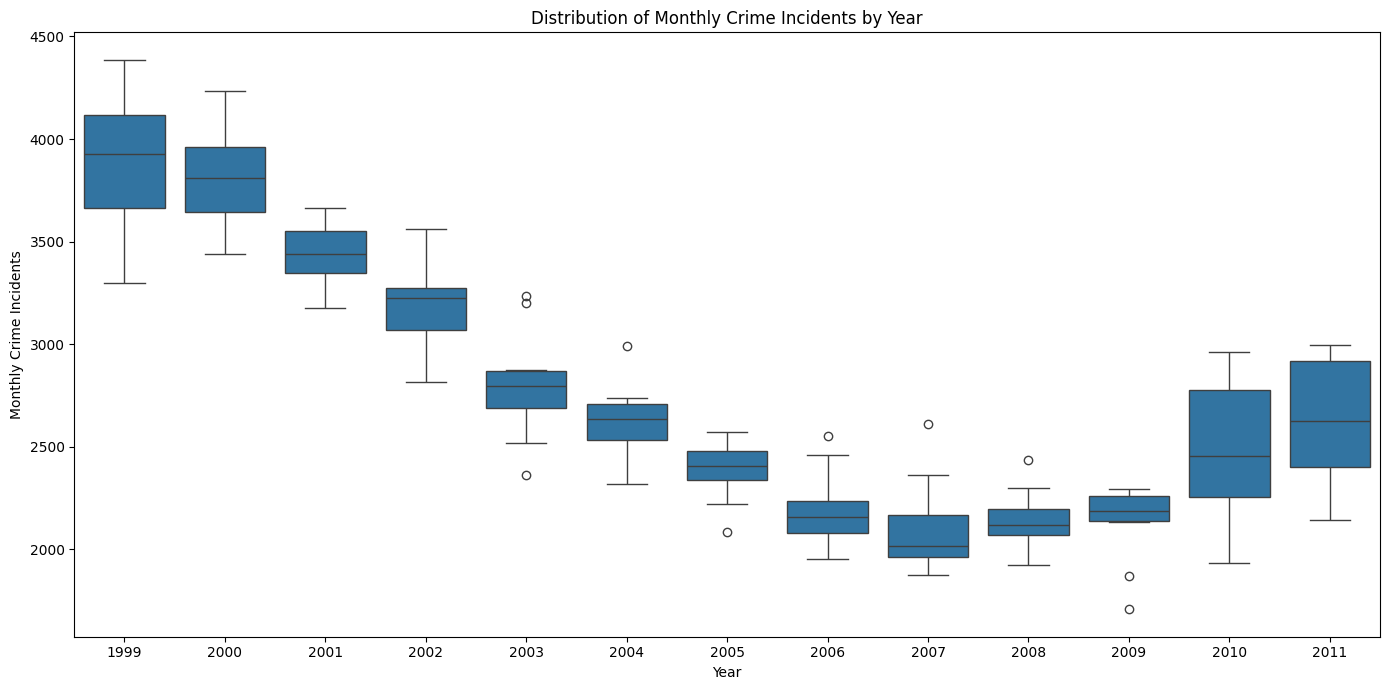

In [109]:
# Bivariate Analysis: Analyze yearly variation in monthly crime volume

# Calculate crime incidents for each Year-Month combination
monthly_counts = (
    df.groupby(['YEAR', 'MONTH'])
      .size()
      .reset_index(name='Incidents')
)

# Create box plot
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=monthly_counts,
    x='YEAR',
    y='Incidents'
)

plt.title('Distribution of Monthly Crime Incidents by Year')
plt.xlabel('Year')
plt.ylabel('Monthly Crime Incidents')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot shows the median, spread, and unusual monthly values for each year, making year-to-year variability easy to compare.

##### 2. What is/are the insight(s) found from the chart?

- The median monthly volume declines from **~3.9K in 1999 to ~2.0K in 2007**, confirming the long-term reduction seen earlier.
- **2010–2011 show a clear upward shift**, with 2011's median around **2.6K** and a wider spread, indicating higher and more variable monthly crime volumes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes**. The changing median and spread indicate that forecasting should account for both long-term trend and monthly variability.

**Negative growth**: The declining monthly medians from 1999–2007 represent reduced crime volume; the later upward shift indicates a reversal that should be investigated further.

#### Chart 5: Crime Incidents by Month - Bar Chart

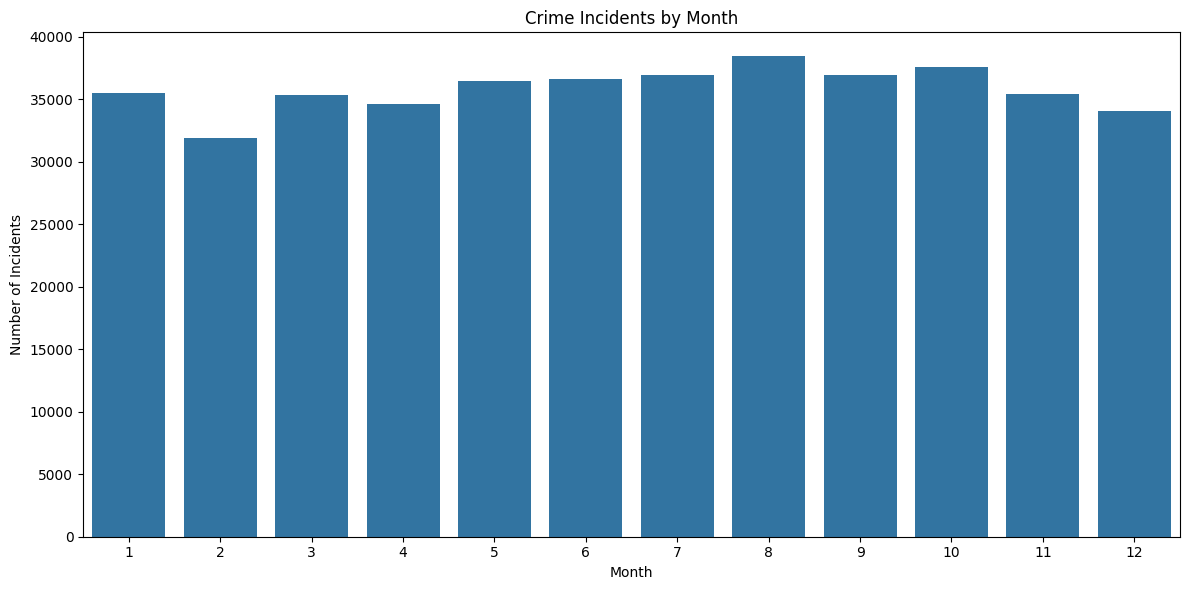

In [110]:
# Univariate Analysis: Analyze seasonal crime patterns across months

# Count the number of recorded crime incidents for each month
monthly_crime = df['MONTH'].value_counts().sort_index()

# Create the bar chart
plt.figure(figsize=(12, 6))

sns.barplot(
    x=monthly_crime.index,
    y=monthly_crime.values
)

# Add chart title and axis labels
plt.title('Crime Incidents by Month')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')

# Display the chart
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart clearly compares crime volume across the 12 months and helps identify monthly patterns

##### 2. What is/are the insight(s) found from the chart?

- August has the highest volume (~ 38.4K incidents), followed by October (~ 37.5K), while February has the lowest (~31.9K).
- Crime volume is generally higher from May to October, indicating a noticeable seasonal pattern.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Monthly patterns can support seasonal patrol planning, staffing, and proactive resource allocation during higher-volume periods.

Negative growth: February shows the lowest incident volume, but this chart represents monthly distribution across all years, not month-over-month growth.

#### Chart 6: Daily Crime Distribution by Day of Week - Violin Plot

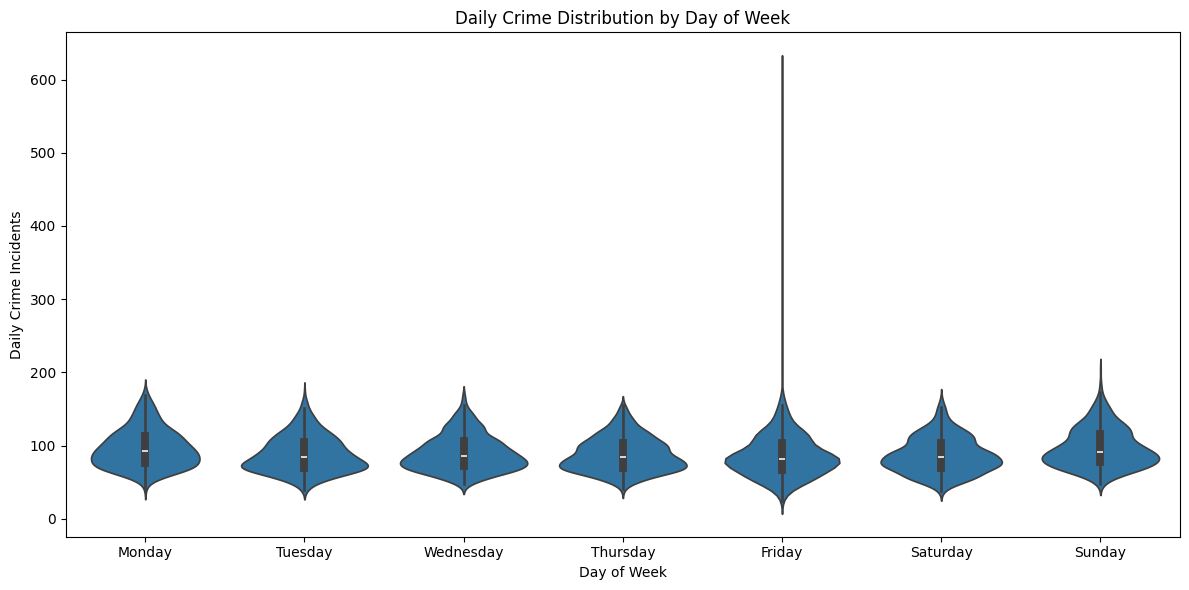

In [111]:
# Univariate Analysis: Analyze daily crime volume variation across the week

# Create a daily crime count
daily_crime = (
    df.groupby('Date')
      .size()
      .reset_index(name='Daily_Incidents')
)

# Extract day of week
daily_crime['Day_of_Week'] = daily_crime['Date'].dt.day_name()

# Define correct weekday order
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Create violin plot
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=daily_crime,
    x='Day_of_Week',
    y='Daily_Incidents',
    order=day_order
)

plt.title('Daily Crime Distribution by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Daily Crime Incidents')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

- **Violin plot** was selected to compare the distribution and variability of daily crime incidents across the seven days of the week, rather than only comparing total counts.

##### 2. What is/are the insight(s) found from the chart?

- **Friday shows the highest variability**, with daily crime counts having a much wider spread and an extreme high value of **600+ incidents** compared with other days.
- **Sunday has a relatively higher typical daily crime volume**, while **Tuesday and Saturday show comparatively lower central distributions**.
- Most weekday distributions are concentrated around roughly **60–120 incidents per day**, but Friday has substantially greater variation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Yes.** The variation across weekdays, particularly the higher variability on **Friday**, can support **day-specific patrol scheduling and resource planning** rather than applying the same coverage across all days.
- **Negative growth:** The chart identifies differences in daily crime volume and variability, but it does **not establish crime growth or decline over time**.

#### Chart 7: Crime Incidents by Hour of Day - Line Chart

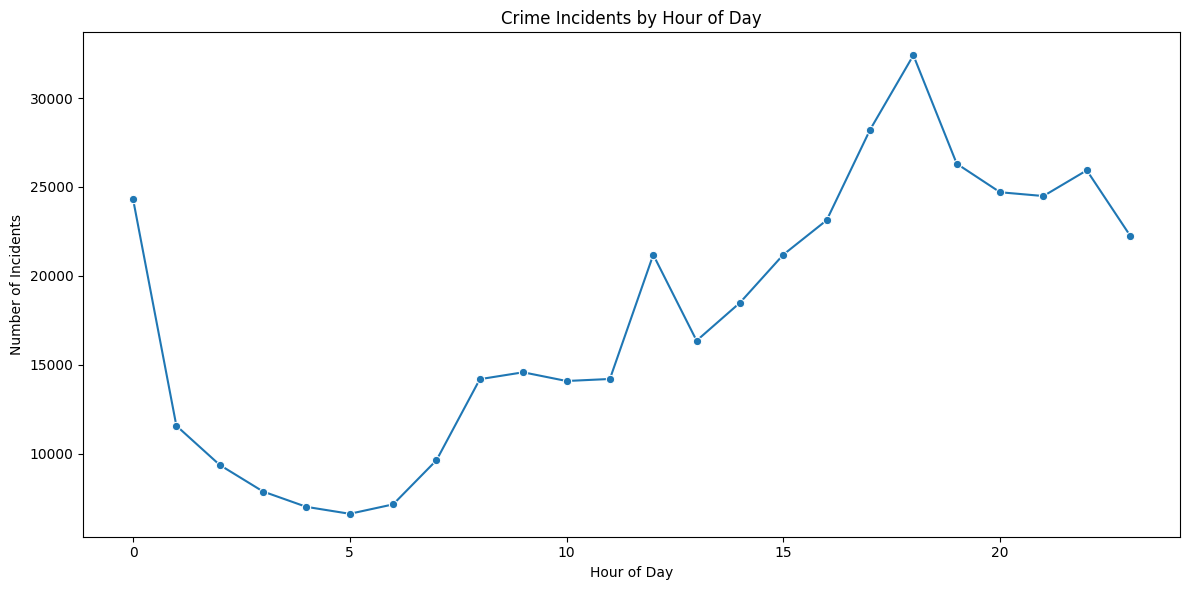

In [112]:
# Univariate Analysis: Analyze crime incident concentration across hours of the day

# Exclude unknown hour values (-1)
hourly_crime = df[df['HOUR'] >= 0]['HOUR'].value_counts().sort_index()

# Create the line chart
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=hourly_crime.index,
    y=hourly_crime.values,
    marker='o'
)

# Add chart title and axis labels
plt.title('Crime Incidents by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Incidents')

# Display the chart neatly
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is appropriate because the 24 hours form an ordered sequence, making the daily crime pattern and peak periods easy to identify.

##### 2. What is/are the insight(s) found from the chart?

- Incidents are lowest around 5 AM (~ 6.6K) and then rise steadily through the day.
- Crime volume peaks at 6 PM (~ 32.4K)—nearly 5× the 5 AM level—before declining through the evening.
- The sharp increase from 12 PM (~21K) to 6 PM highlights the late-afternoon/evening period as a key concentration window.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong concentration around 12 PM–10 PM can support more targeted patrol coverage and staffing by time of day, rather than treating all hours equally.

Negative growth: The chart does not measure growth; it identifies time-of-day concentration, so no growth conclusion should be made from it alone.

#### Chart 8: Top 10 Crime Types by Number of Incidents - Bar Chart

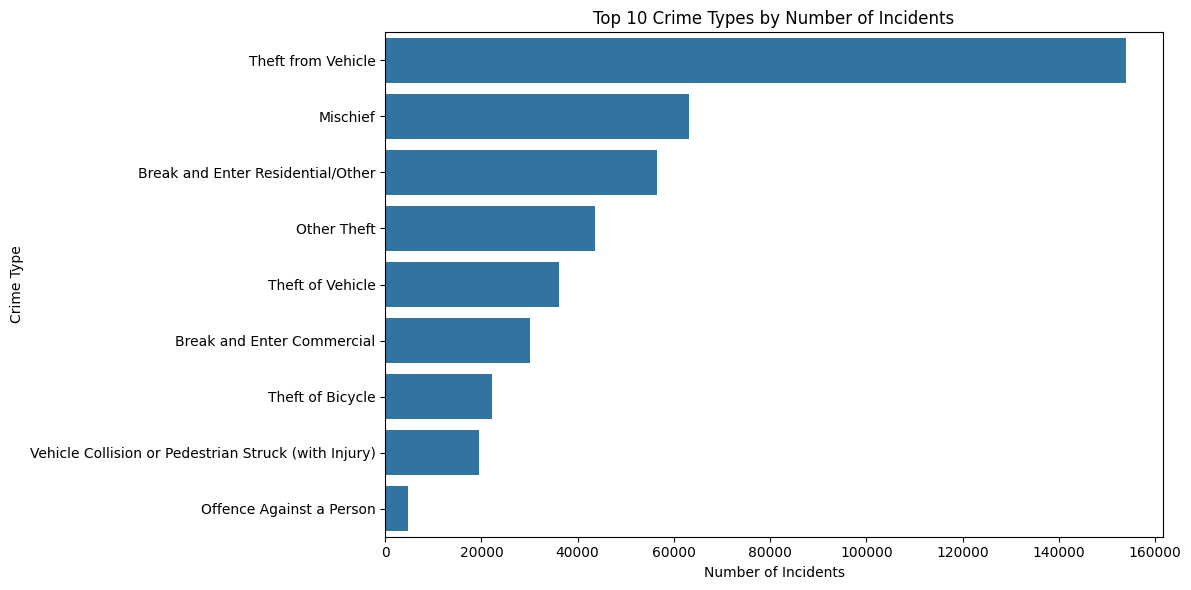

In [113]:
# Univariate Analysis: Identify the highest-volume crime categories

# Count the number of crime incidents for each crime type
crime_type_counts = df['TYPE'].value_counts().head(10)

# Create the bar chart
plt.figure(figsize=(12, 6))

sns.barplot(
    x=crime_type_counts.values,
    y=crime_type_counts.index
)

# Add chart title and axis labels
plt.title('Top 10 Crime Types by Number of Incidents')
plt.xlabel('Number of Incidents')
plt.ylabel('Crime Type')

# Display the chart neatly
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected because TYPE is a categorical variable with multiple crime categories. It allows us to clearly compare incident volumes and identify which crime types contribute most to the recorded crime activity.

##### 2. What is/are the insight(s) found from the chart?

- Theft from Vehicle accounts for ~ 153K incidents (~36% of all records), making it the dominant crime category and a clear priority for deeper hotspot/time analysis.
- Mischief and residential break-and-enter contribute ~63K and ~56K incidents respectively, showing that a small number of categories drive a large share of the recorded crime workload.
- The distribution is highly concentrated, so subsequent analysis should focus on these high-volume categories to identify where and when targeted prevention could have the greatest operational relevance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying high-volume crime categories helps prioritize patrol planning, preventive measures, and resource allocation.

Negative growth: No negative-growth conclusion can be drawn from this chart alone; it shows crime volume, not growth over time.

#### Chart 9: Pareto Analysis of Crime Types - Pareto Chart

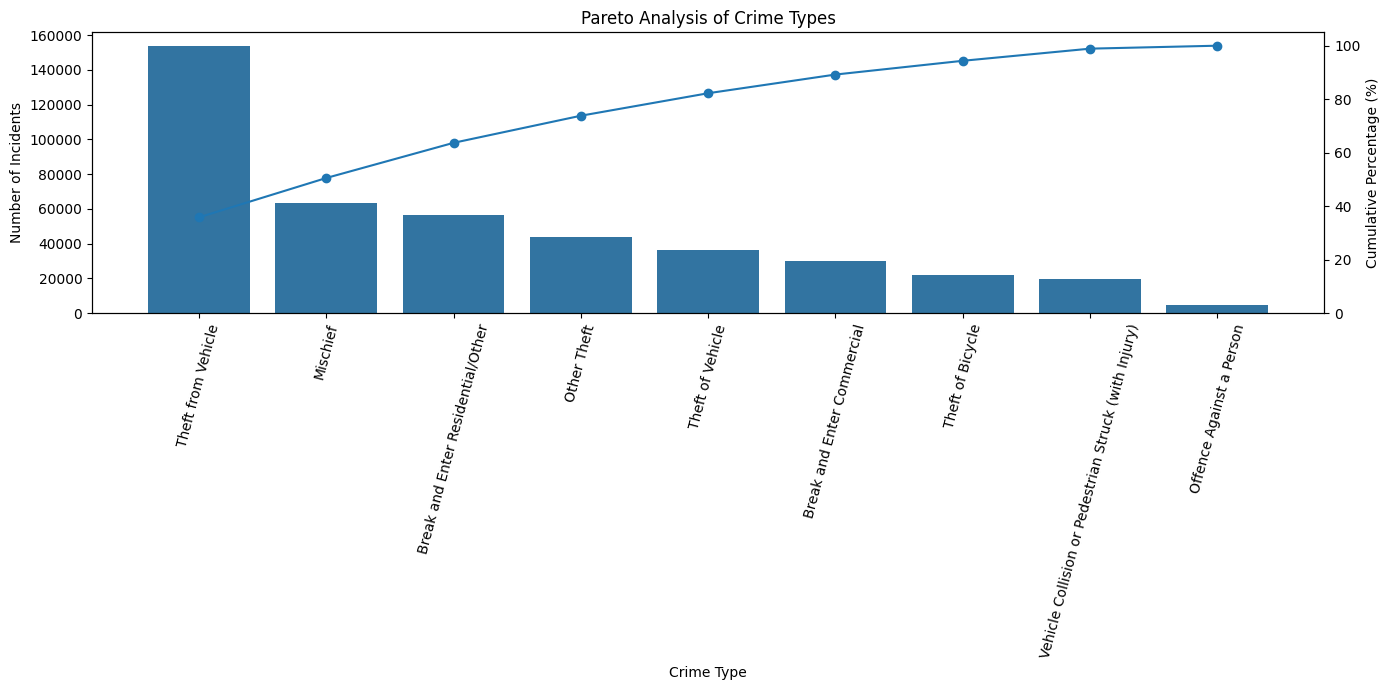

In [114]:
# Multivariate Analysis: Analyze cumulative contribution of major crime categories

# Count incidents for each crime type
crime_counts = df['TYPE'].value_counts().reset_index()

crime_counts.columns = ['Crime_Type', 'Incidents']

# Calculate percentage contribution
crime_counts['Percentage'] = (
    crime_counts['Incidents'] /
    crime_counts['Incidents'].sum()
) * 100

# Calculate cumulative percentage
crime_counts['Cumulative_Percentage'] = (
    crime_counts['Percentage'].cumsum()
)

# Create Pareto chart for top 15 crime types
pareto_data = crime_counts.head(15)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar chart - incident count
sns.barplot(
    data=pareto_data,
    x='Crime_Type',
    y='Incidents',
    ax=ax1
)

ax1.set_title('Pareto Analysis of Crime Types')
ax1.set_xlabel('Crime Type')
ax1.set_ylabel('Number of Incidents')
ax1.tick_params(axis='x', rotation=75)

# Cumulative percentage line
ax2 = ax1.twinx()

ax2.plot(
    range(len(pareto_data)),
    pareto_data['Cumulative_Percentage'],
    marker='o'
)

ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

- **Pareto chart** was selected to identify the crime types that contribute most to the overall crime volume and to show their **cumulative contribution**.
- It combines individual crime volumes with cumulative percentage, making it easier to identify where the majority of recorded incidents are concentrated.

##### 2. What is/are the insight(s) found from the chart?

- **Theft from Vehicle is the dominant category with ~153K incidents**, followed by **Mischief (~63K)** and **Break and Enter Residential/Other (~56K)**.
- The cumulative contribution rises rapidly: the **top 5 crime types account for roughly 80% of the incidents** shown in the analysis, indicating strong concentration among major crime categories.
- Adding the remaining categories gradually moves the cumulative contribution toward **~100%**, showing that a relatively smaller set of crime types drives most of the recorded volume.

#### Chart 10: Top 10 Neighbourhoods by Crime Incidents - Bar Chart

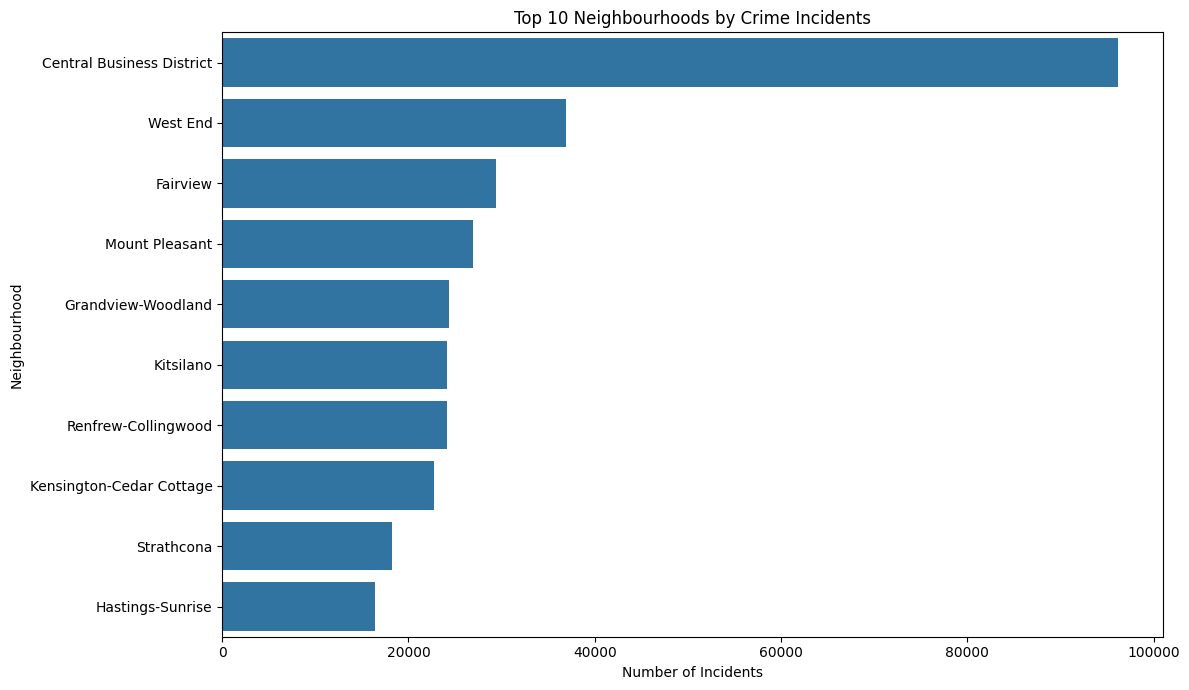

In [115]:
# Univariate Analysis: Identify neighbourhoods with the highest crime volume

# Exclude "Unknown" neighbourhoods and count incidents
neighbourhood_crime = (
    df[df['NEIGHBOURHOOD'] != 'Unknown']['NEIGHBOURHOOD']
    .value_counts()
    .head(10)
)

# Create the horizontal bar chart
plt.figure(figsize=(12, 7))

sns.barplot(
    x=neighbourhood_crime.values,
    y=neighbourhood_crime.index
)

# Add chart title and axis labels
plt.title('Top 10 Neighbourhoods by Crime Incidents')
plt.xlabel('Number of Incidents')
plt.ylabel('Neighbourhood')

# Display the chart
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **horizontal bar chart** makes it easy to compare crime concentration across neighbourhoods and identify locations requiring deeper analysis.

##### 2. What is/are the insight(s) found from the chart?

- **Central Business District records ~ 96K incidents**, around **22% of the cleaned dataset** and more than **2.5× West End (~37K)**, showing a strong geographic concentration of recorded crime.
- The remaining top neighbourhoods are much closer together, generally around **16K–29K** incidents, suggesting the CBD is a distinct high-volume location rather than a uniform pattern across neighbourhoods.
- This makes the **CBD a key location for further drill-down by crime type** and hour rather than assuming the same intervention is appropriate everywhere.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Location-level concentration can support **targeted patrol deployment, resource prioritization, and hotspot-level analysis** instead of distributing resources uniformly.

**Negative growth**: This chart shows **total incident concentration by neighbourhood**, not change over time, so it cannot establish whether crime is increasing or decreasing in any neighbourhood.

#### Chart 11: Geographic Distribution of Crime Incidents - Scatter Plot

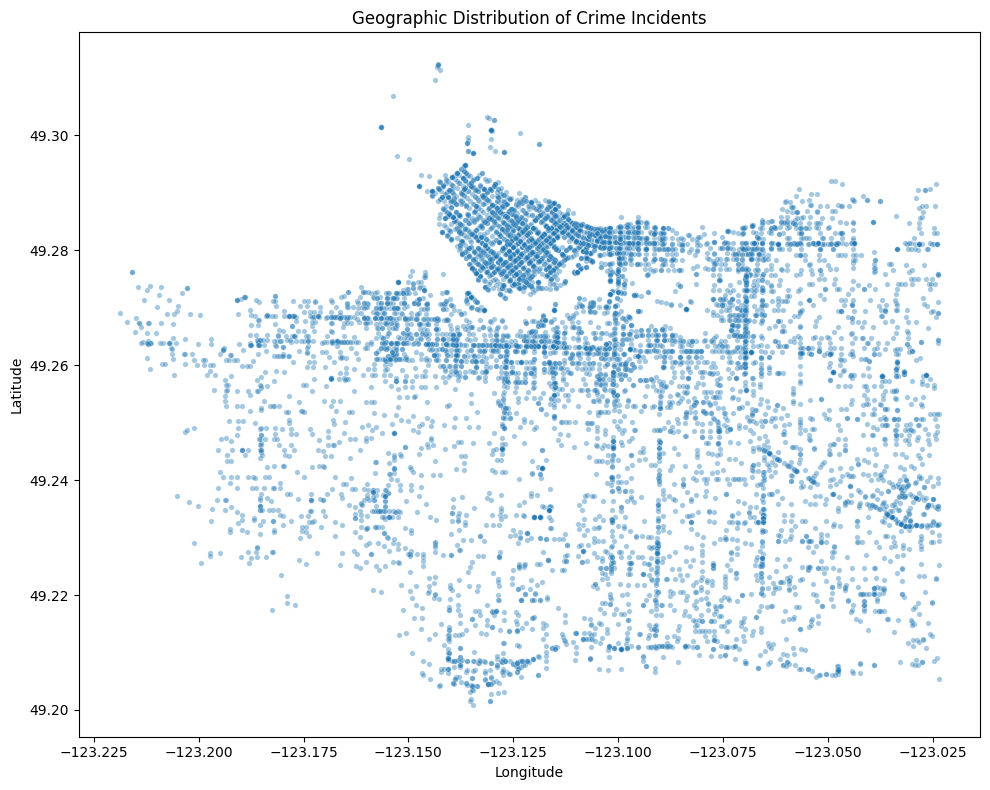

In [116]:
# Bivariate Analysis: Analyze the spatial distribution of crime incidents

# Keep only valid geographic coordinates
geo_df = df[
    (df['Latitude'] != 0) &
    (df['Longitude'] != 0)
].copy()

# Sample records for visualization
geo_sample = geo_df.sample(
    n=min(10000, len(geo_df)),
    random_state=42
)

# Create geographic scatter plot
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=geo_sample,
    x='Longitude',
    y='Latitude',
    alpha=0.4,
    s=15
)

plt.title('Geographic Distribution of Crime Incidents')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **scatter plot** shows the spatial distribution of incidents using latitude and longitude, making geographic clusters easier to identify.

##### 2. What is/are the insight(s) found from the chart?

- Crime incidents are **densely clustered around the central area**, particularly between approximately **49.24–49.29 latitude and -123.15 to -123.05 longitude**.
- The distribution is not uniform; several **high-density spatial clusters** are visible, while the outer areas contain comparatively fewer incidents.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes**. Identifying spatial concentrations can support **hotspot-focused patrol planning and geographic resource allocation**.

**Negative growth**: This chart shows **where incidents are concentrated**, not how crime changes over time, so no growth conclusion can be drawn.

#### Chart 12: Top Crime Types Across High-Volume Neighbourhoods - Heatmap


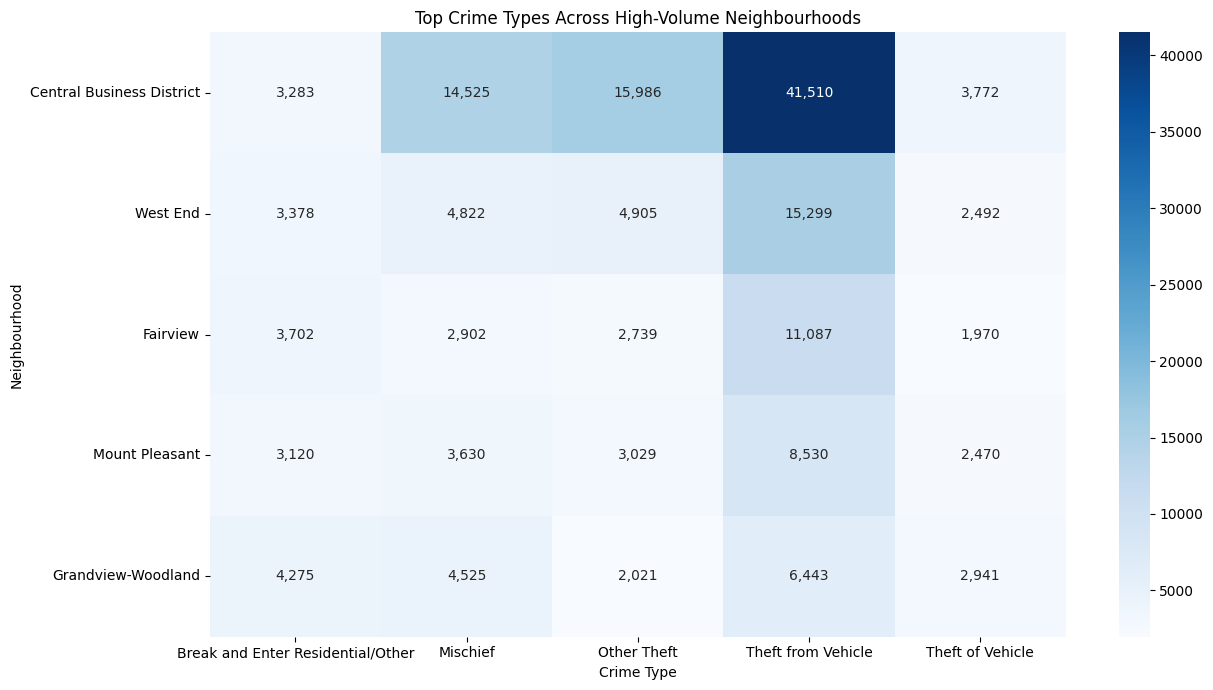

In [117]:
# Bivariate Analysis: Analyze crime-type concentration across neighbourhoods

# Select top 5 neighbourhoods by total crime incidents
top_neighbourhoods = (
    df[df['NEIGHBOURHOOD'] != 'Unknown']['NEIGHBOURHOOD']
    .value_counts()
    .head(5)
    .index
)

# Select top 5 crime types by total incidents
top_crimes = df['TYPE'].value_counts().head(5).index

# Filter dataset
crime_location = df[
    df['NEIGHBOURHOOD'].isin(top_neighbourhoods) &
    df['TYPE'].isin(top_crimes)
]

# Create a crime type vs neighbourhood count table
crime_location_table = pd.crosstab(
    crime_location['NEIGHBOURHOOD'],
    crime_location['TYPE']
)

# Order neighbourhoods by their total incidents within selected crime types
crime_location_table['Total'] = crime_location_table.sum(axis=1)
crime_location_table = crime_location_table.sort_values(
    'Total', ascending=False
).drop(columns='Total')

# Create heatmap
plt.figure(figsize=(13, 7))

sns.heatmap(
    crime_location_table,
    annot=True,
    fmt=',',
    cmap='Blues'
)

# Add chart title and labels
plt.title('Top Crime Types Across High-Volume Neighbourhoods')
plt.xlabel('Crime Type')
plt.ylabel('Neighbourhood')

# Display the chart neatly
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **heatmap** is ideal for comparing two categorical variables simultaneously and quickly identifying **crime-type concentrations within specific neighbourhoods**.

##### 2. What is/are the insight(s) found from the chart?

- **Central Business District is a major concentration point for Theft from Vehicle (41,510 incidents)**, nearly **2.7× its West End volume (15,299)** and far above other neighbourhoods shown.
- The CBD also records **15,986 Other Theft and 14,525** Mischief incidents, showing that its high overall volume is driven by multiple major crime categories.
- **Grandview-Woodland stands out for Break and Enter Residential/Other (4,275)**, while **Kitsilano has the lowest Theft of Vehicle count (2,252)** among the neighbourhoods shown.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes**. The concentration of specific crime types by neighbourhood supports **targeted, location-specific prevention and patrol planning** rather than applying the same strategy across all areas.

**Negative growth**: This chart compares **incident volumes**, not changes across time, so it cannot establish whether any neighbourhood or crime type is growing or declining.

#### Chart 13: Crime Type Concentration by Hour of Day - Heatmap

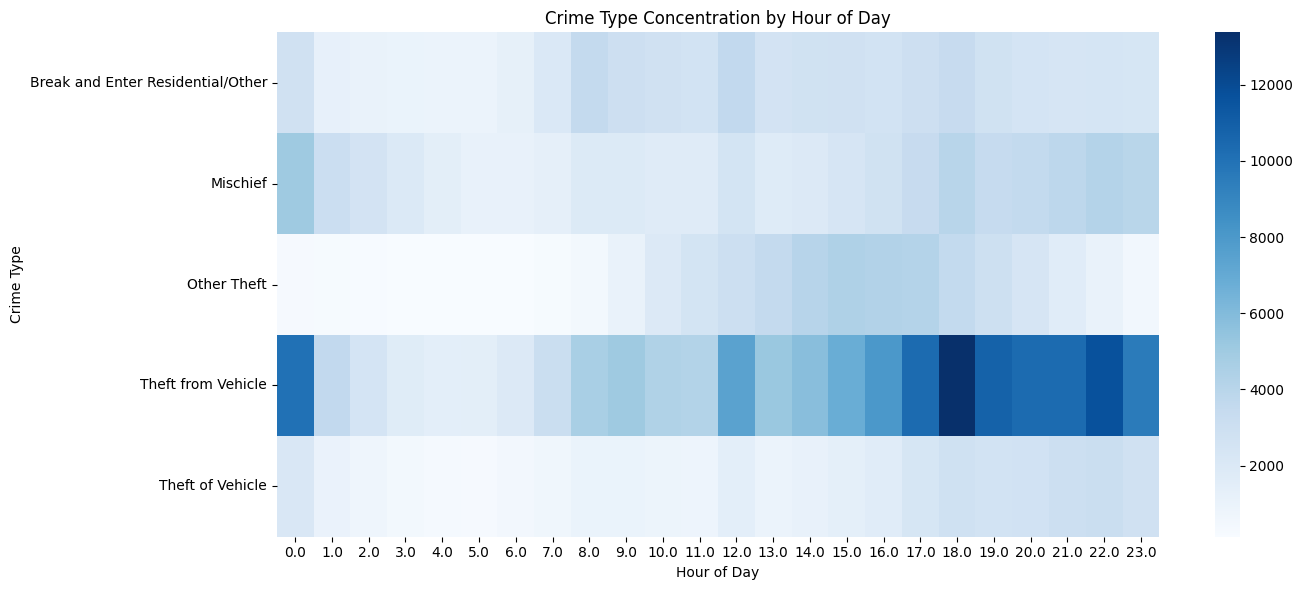

In [118]:
# Bivariate Analysis: Analyze crime-type concentration across hours

# Select the top 5 crime types
top_crimes = df['TYPE'].value_counts().head(5).index

# Exclude unknown hours and keep only top crime types
crime_hour = df[
    (df['HOUR'] >= 0) &
    (df['TYPE'].isin(top_crimes))
]

# Create crime type vs hour count table
crime_hour_table = pd.crosstab(
    crime_hour['TYPE'],
    crime_hour['HOUR']
)

# Create heatmap
plt.figure(figsize=(14, 6))

sns.heatmap(
    crime_hour_table,
    cmap='Blues'
)

# Add title and labels
plt.title('Crime Type Concentration by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Crime Type')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A **heatmap** is useful here because it shows the interaction between **crime type and hour**, making high-concentration time windows immediately visible.

##### 2. What is/are the insight(s) found from the chart?

- **Theft from Vehicle has the strongest time concentration**, reaching roughly **13K+ incidents around 6 PM**, with elevated levels continuing through the evening.
- **Mischief is more evenly distributed across the day**, while **Other Theft increases noticeably from the afternoon** into the evening.
- The patterns show that the **6–10 PM period is not equally important for every crime type—the concentration** is particularly pronounced for Theft from Vehicle.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes**. Combining crime type with time allows more precise **patrol scheduling and prevention** planning—for example, prioritizing vehicle-related crime during its strongest evening window.

**Negative growth:** This chart does not measure growth over time; it identifies **hour-specific concentration**, so increasing/decreasing crime cannot be concluded from it.

#### Chart 14: Crime Volume Contribution by Top 5 Neighbourhoods - Stacked Area Chart


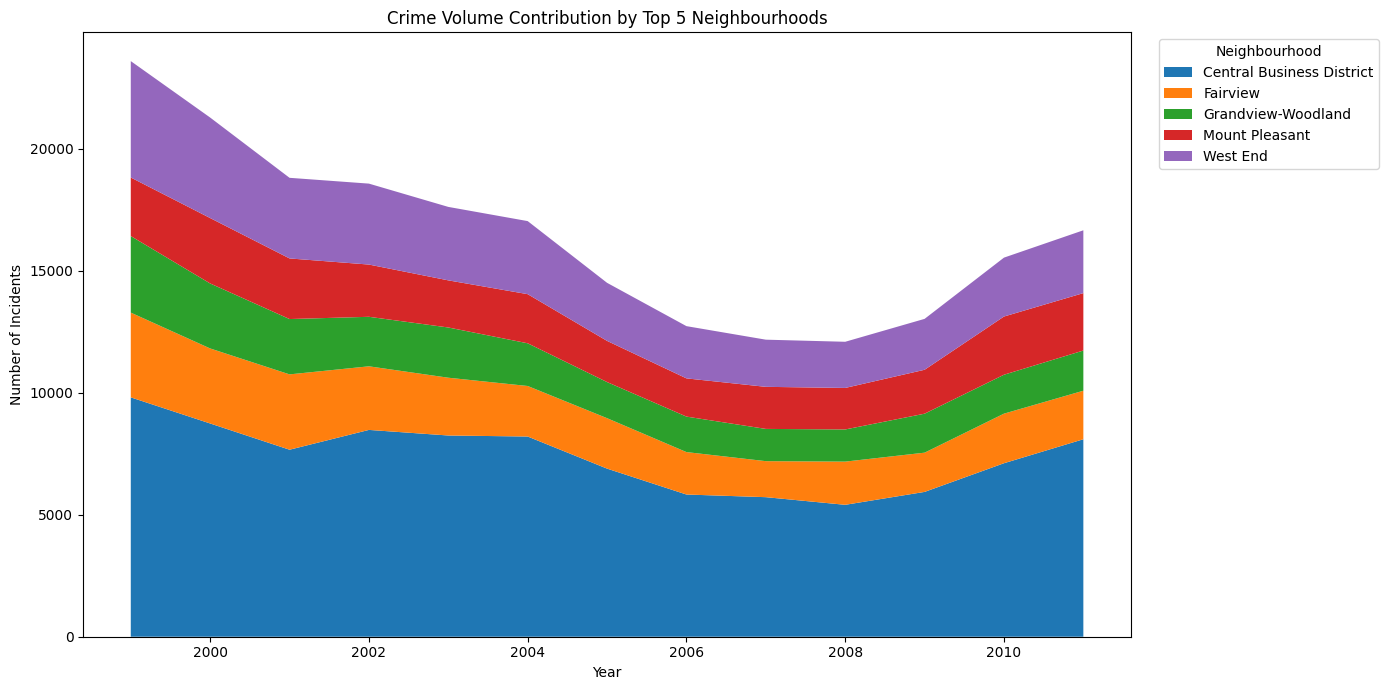

In [119]:
# Multivariate Analysis: Analyze neighbourhood crime volume changes over time

# Select top 5 neighbourhoods
top_neighbourhoods = (
    df[df['NEIGHBOURHOOD'] != 'Unknown']['NEIGHBOURHOOD']
    .value_counts()
    .head(5)
    .index
)

# Calculate yearly incidents
neighbourhood_yearly = (
    df[df['NEIGHBOURHOOD'].isin(top_neighbourhoods)]
    .groupby(['YEAR', 'NEIGHBOURHOOD'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Create stacked area chart
plt.figure(figsize=(14, 7))

plt.stackplot(
    neighbourhood_yearly.index,
    *[neighbourhood_yearly[col] for col in neighbourhood_yearly.columns],
    labels=neighbourhood_yearly.columns
)

plt.title('Crime Volume Contribution by Top 5 Neighbourhoods')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')

plt.legend(
    title='Neighbourhood',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

- A **stacked area chart** shows how the crime volume of the top 5 neighbourhoods changes over time while also showing their contribution to the combined volume.

- It is useful for **comparing multiple neighbourhoods without the overlapping-line problem**.

##### 2. What is/are the insight(s) found from the chart?

- **Central Business District remains the largest contributor throughout 1999–2011**, falling from roughly**9.8K incidents in 1999 to ~5.4K in 2008**, before recovering to ~8.0K by 2011.
- The combined crime volume across these five neighbourhoods drops from about **23.5K in 1999 to ~12K in 2007–08**, then rises to around **16.7K by 2011**.
- **West End, Fairview, Grandview-Woodland, and Mount Pleasant generally follow the same broad decline-and-recovery pattern**, indicating that the long-term change is not isolated to one neighbourhood.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes**. The concentration of crime volume in the Central Business District and the later recovery across multiple neighbourhoods can support **location-specific resource planning and future crime forecasting**.

**Negative growth**: The chart shows a substantial decline followed by recovery, but it does **not explain why** those changes occurred. The causes should be investigated separately rather than inferred from this chart.

#### Chart 15: Crime-Type Composition by Year — 100% Stacked Bar Chart

<Figure size 1400x700 with 0 Axes>

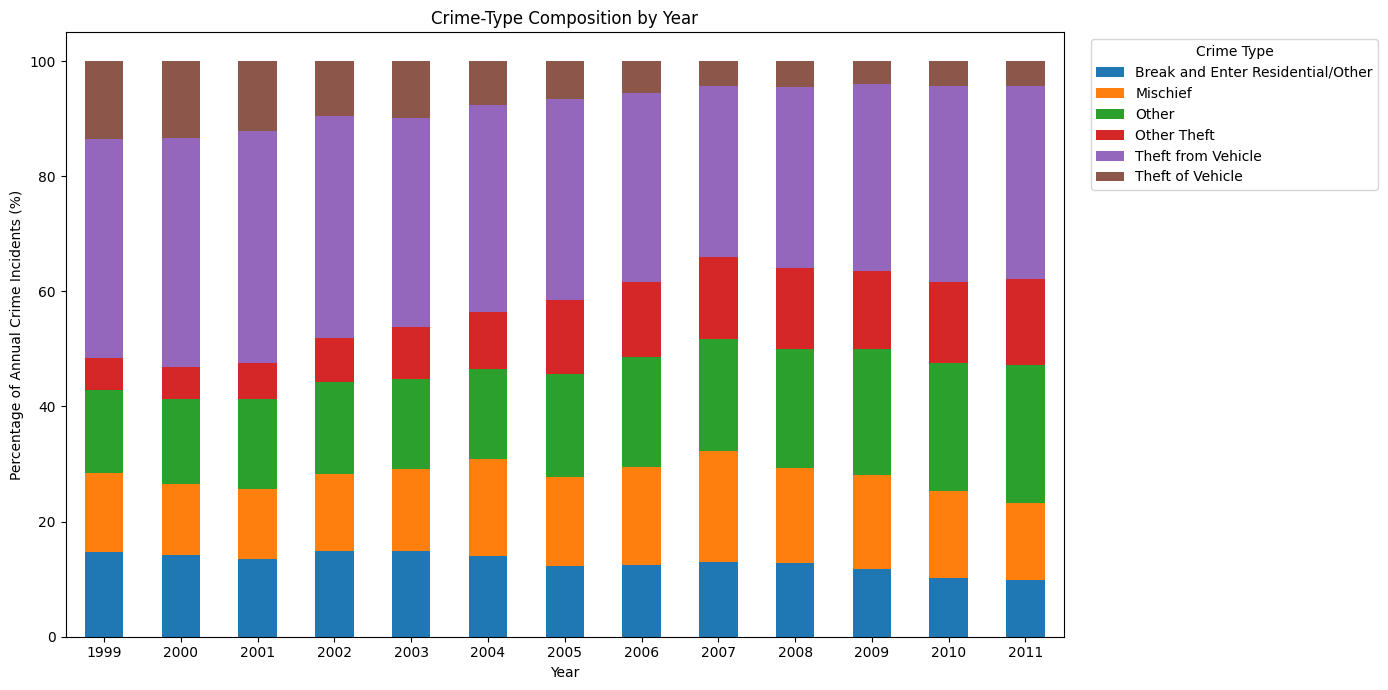

In [120]:
# Multivariate Analysis: Analyze how crime-type composition changes over years

# Select the top 5 crime types
top_crimes = df['TYPE'].value_counts().head(5).index

# Group all remaining crime types as "Other"
crime_composition = df.copy()

crime_composition['Crime_Group'] = np.where(
    crime_composition['TYPE'].isin(top_crimes),
    crime_composition['TYPE'],
    'Other'
)

# Calculate yearly percentage composition
yearly_composition = pd.crosstab(
    crime_composition['YEAR'],
    crime_composition['Crime_Group'],
    normalize='index'
) * 100

# Create 100% stacked bar chart
plt.figure(figsize=(14, 7))

yearly_composition.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)

plt.title('Crime-Type Composition by Year')
plt.xlabel('Year')
plt.ylabel('Percentage of Annual Crime Incidents (%)')

plt.xticks(rotation=0)

plt.legend(
    title='Crime Type',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

- **100% stacked bar chart** was selected to compare the **percentage composition of major crime types across years** and identify how the crime mix changes over time.

##### 2. What is/are the insight(s) found from the chart?

- **Theft from Vehicle remains the largest contributor** across all years, although its share decreases from about **38% in 1999 to around 34% in 2011**.
- **Other Theft increases steadily**, from roughly **4% in 1999 to about 15% in 2011**, while **Mischief and Break and Enter Residential/Other** show relatively smaller changes in their annual shares.
- The changing composition indicates that the **mix of crime types is not constant over time**, even when comparing the same major categories.

##### 3. Will the gained insights help create a positive business impact? Any insights that lead to negative growth?

- **Yes.** Understanding changes in crime-type composition can support **category-specific prevention strategies, patrol planning, and resource allocation** over different periods.
- **Negative growth:** The chart shows changes in **crime composition**, not overall crime growth or decline. A decreasing share of one category does not necessarily mean its actual incident count decreased.

#### Chart 16: Distribution of Monthly Crime Incidents — Histogram

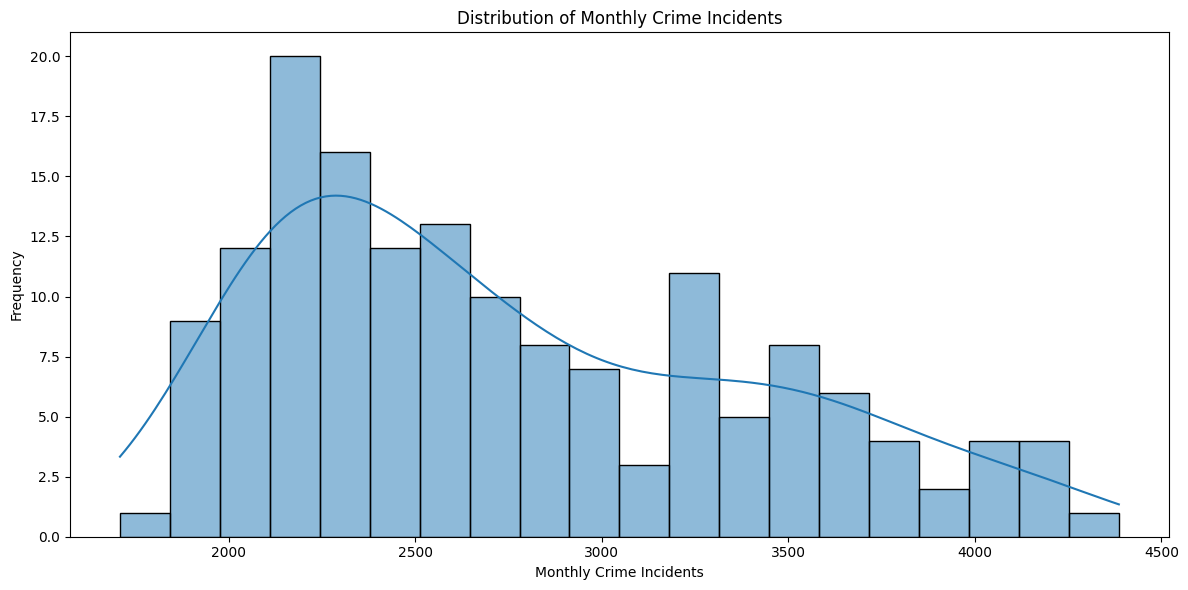

In [121]:
# Univariate Analysis: Analyze the distribution of the monthly prediction target

# Calculate total crime incidents for each year-month
monthly_crime_counts = (
    df.groupby(['YEAR', 'MONTH'])
      .size()
      .reset_index(name='Monthly_Incidents')
)

# Create histogram
plt.figure(figsize=(12, 6))

sns.histplot(
    data=monthly_crime_counts,
    x='Monthly_Incidents',
    bins=20,
    kde=True
)

plt.title('Distribution of Monthly Crime Incidents')
plt.xlabel('Monthly Crime Incidents')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

- **Histogram** was selected to understand how monthly crime incidents are distributed across the dataset and to identify the typical range and spread of monthly crime volumes.

##### 2. What is/are the insight(s) found from the chart?

- Most months record approximately **2,000–2,700 incidents**, with the highest concentration around **2,200–2,400 incidents**.
- The distribution is **right-skewed**, with monthly crime volumes extending from roughly **1,700 to 4,300 incidents**.
- A smaller number of months have substantially higher volumes above **3,000 incidents**, indicating greater variation in monthly crime activity.

##### 3. Will the gained insights help create a positive business impact? Any insights that lead to negative growth?

- **Yes.** Understanding the typical monthly crime range and the presence of high-volume months can help establish **realistic forecasting ranges and resource requirements** for monthly public-safety planning.
- **Negative growth:** The higher-volume months are not necessarily negative growth; they represent **variation in monthly crime volume**. The causes of these higher values require further analysis.

#### Chart 17: Correlation Heatmap of Numerical Features

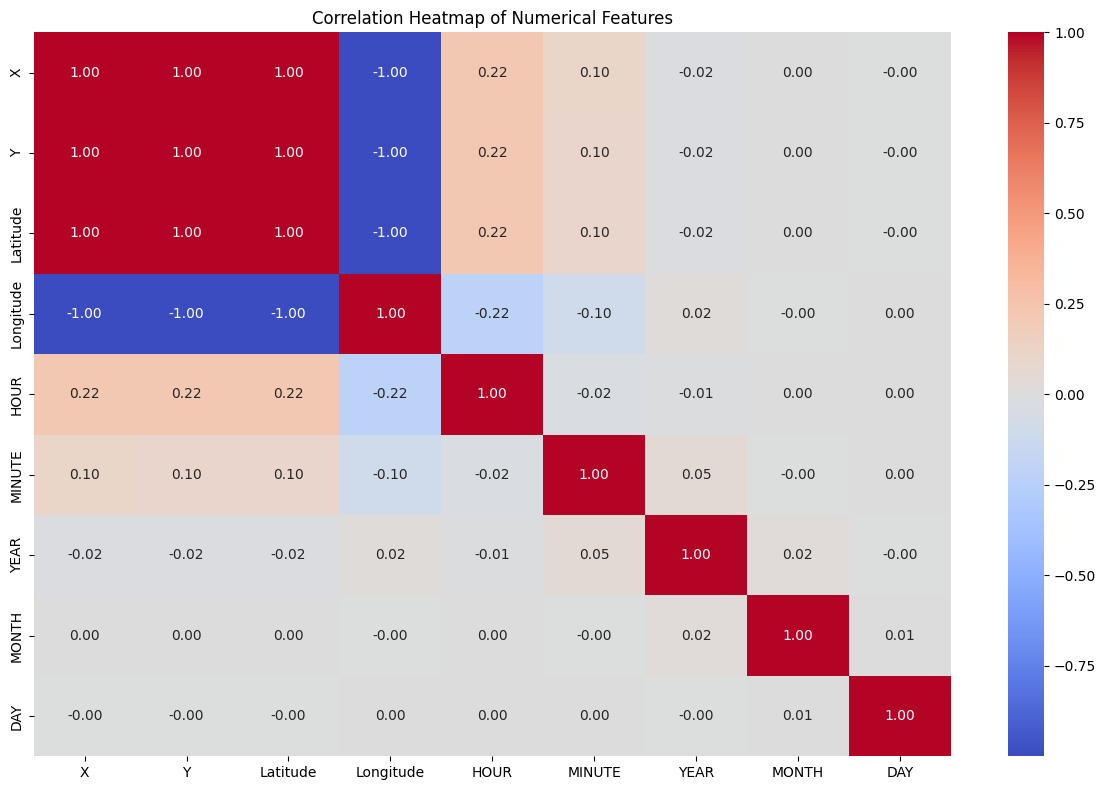

In [122]:
# Bivariate Analysis: Analyze relationships among numerical features

# Select meaningful numerical variables
correlation_features = [
    'X', 'Y',
    'Latitude', 'Longitude',
    'HOUR', 'MINUTE',
    'YEAR', 'MONTH', 'DAY'
]

# Calculate correlation matrix
correlation_matrix = df[correlation_features].corr()

# Create heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

**Correlation heatmap** was selected to identify relationships between numerical features and detect potential multicollinearity before feature selection and model building.

##### 2. What is/are the insight(s) found from the chart?

- **X, Y, and Latitude are almost perfectly positively correlated (~1.00)**, while** Longitude has an almost perfect negative correlation (~−1.00)** with them, indicating strong redundancy among geographic variables.
- **HOUR has only a weak relationship with the geographic variables (~0.22)**, while **YEAR, MONTH, and DAY show near-zero correlations** with most numerical features.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the chart experiments conducted during Exploratory Data Analysis (EDA), the following three hypothetical statements were formulated for statistical testing:

1. Monthly crime incident volumes differ significantly between the periods 1999–2005 and 2006–2011.

2. Daily crime incident volumes differ significantly between weekdays and weekends.

3. There is a statistically significant association between crime type and time of day.

These statements will be evaluated using appropriate statistical tests to determine whether the observed patterns are statistically significant.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no statistically significant difference in monthly crime incident volumes between 1999–2005 and 2006–2011.

Alternative Hypothesis (H₁):
There is a statistically significant difference in monthly crime incident volumes between 1999–2005 and 2006–2011.

#### 2. Perform an appropriate statistical test.

In [123]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import mannwhitneyu

# Create monthly crime incident counts
monthly_crime = (
    df.groupby(['YEAR', 'MONTH'])
      .size()
      .reset_index(name='Monthly_Incidents')
)

# Divide the data into two time periods
early_period = monthly_crime[
    monthly_crime['YEAR'].between(1999, 2005)
]['Monthly_Incidents']

later_period = monthly_crime[
    monthly_crime['YEAR'].between(2006, 2011)
]['Monthly_Incidents']

# Perform Mann–Whitney U test
statistic, p_value = mannwhitneyu(
    early_period,
    later_period,
    alternative='two-sided'
)

print("Mann–Whitney U Statistic:", statistic)
print("P-Value:", p_value)

# Interpret the result
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in monthly crime volumes.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in monthly crime volumes.")

Mann–Whitney U Statistic: 5539.0
P-Value: 3.9265686707187775e-19
Reject the null hypothesis.
There is a statistically significant difference in monthly crime volumes.


##### Which statistical test have you done to obtain P-Value?

I used the Mann–Whitney U test to compare monthly crime incident volumes between 1999–2005 and 2006–2011.

##### Why did you choose the specific statistical test?

I chose the Mann–Whitney U test because it is a non-parametric test used to compare two independent groups without assuming that the data follows a normal distribution. It is suitable for comparing monthly crime incident-count distributions across two time periods.

##### Conclusion

Your p-value is 3.9265686707187775e-19, which is less than 0.05.
Therefore, you reject the null hypothesis. The result indicates a statistically significant difference in monthly crime volumes between the two time periods.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no statistically significant difference in daily crime incident volumes between weekdays and weekends.

Alternative Hypothesis (H₁):
There is a statistically significant difference in daily crime incident volumes between weekdays and weekends.

#### 2. Perform an appropriate statistical test.

In [124]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import mannwhitneyu

# Create daily crime incident counts
daily_crime = (
    df.groupby('Date')
      .size()
      .reset_index(name='Daily_Incidents')
)

# Extract the day of the week
daily_crime['Day_of_Week'] = daily_crime['Date'].dt.day_name()

# Classify days as weekdays or weekends
daily_crime['Day_Type'] = daily_crime['Day_of_Week'].apply(
    lambda day: 'Weekend'
    if day in ['Saturday', 'Sunday']
    else 'Weekday'
)

# Separate daily incident counts
weekday_crime = daily_crime[
    daily_crime['Day_Type'] == 'Weekday'
]['Daily_Incidents']

weekend_crime = daily_crime[
    daily_crime['Day_Type'] == 'Weekend'
]['Daily_Incidents']

# Perform Mann–Whitney U test
statistic, p_value = mannwhitneyu(
    weekday_crime,
    weekend_crime,
    alternative='two-sided'
)

print("Mann–Whitney U Statistic:", statistic)
print("P-Value:", p_value)

# Interpret the result
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in daily crime volumes.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in daily crime volumes.")

Mann–Whitney U Statistic: 2187683.0
P-Value: 0.008030689431498109
Reject the null hypothesis.
There is a statistically significant difference in daily crime volumes.


##### Which statistical test have you done to obtain P-Value?

The Mann–Whitney U test was performed to compare daily crime incident volumes between weekdays and weekends.

##### Why did you choose the specific statistical test?

The Mann–Whitney U test was selected because it is a non-parametric test used to compare two independent groups. It does not require the data to follow a normal distribution and is suitable for comparing daily crime incident volumes between weekdays and weekends.

##### Conclusion

The p-value of 0.00803 is less than the significance level of 0.05. Therefore, the null hypothesis is rejected. This indicates a statistically significant difference in daily crime incident volumes between weekdays and weekends. However, statistical significance alone does not establish the reason for this difference.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no statistically significant association between crime type and time of day.

Alternative Hypothesis (H₁):
There is a statistically significant association between crime type and time of day.

#### 2. Perform an appropriate statistical test.

In [125]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chi2_contingency

# Create a copy for hypothesis testing
df_hypothesis = df.copy()

# Remove records with missing or invalid hour values
df_hypothesis = df_hypothesis[
    df_hypothesis['HOUR'].between(0, 23)
].copy()

# Create time-of-day categories
df_hypothesis['Time_of_Day'] = pd.cut(
    df_hypothesis['HOUR'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

# Create contingency table
contingency_table = pd.crosstab(
    df_hypothesis['TYPE'],
    df_hypothesis['Time_of_Day']
)

# Perform Chi-square test of independence
chi2_statistic, p_value, degrees_freedom, expected = chi2_contingency(
    contingency_table
)

print("Chi-square Statistic:", chi2_statistic)
print("P-Value:", p_value)
print("Degrees of Freedom:", degrees_freedom)

# Interpret the result
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print(
        "There is a statistically significant association "
        "between crime type and time of day."
    )
else:
    print("Fail to reject the null hypothesis.")
    print(
        "There is no statistically significant association "
        "between crime type and time of day."
    )

Chi-square Statistic: 41414.09795852505
P-Value: 0.0
Degrees of Freedom: 21
Reject the null hypothesis.
There is a statistically significant association between crime type and time of day.


##### Which statistical test have you done to obtain P-Value?

The Chi-square test of independence was performed to examine the association between crime type and time of day.

##### Why did you choose the specific statistical test?

The Chi-square test of independence was selected because both variables are categorical: crime type and time-of-day category. The test determines whether there is a statistically significant association between these two variables.

##### Conclusion

##### Conclusion

I used the **Chi-square test of independence** to examine whether crime type and time of day are associated.

The test produced the following results:

- **Chi-square Statistic:** 41414.10
- **P-Value:** 0.0
- **Degrees of Freedom:** 21

Since the p-value is less than 0.05, I rejected the null hypothesis.

This indicates a statistically significant association between crime type and time of day. Therefore, the distribution of crime types varies across different time-of-day categories.

However, this statistical association does not establish a causal relationship between time of day and crime type.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [126]:
# Handling Missing Values & Missing Value Imputation

# Verify missing values after data wrangling
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
TYPE             0
HUNDRED_BLOCK    0
NEIGHBOURHOOD    0
X                0
Y                0
Latitude         0
Longitude        0
HOUR             0
MINUTE           0
YEAR             0
MONTH            0
DAY              0
Date             0
dtype: int64

Total missing values: 0


#### What all missing value imputation techniques have you used and why did you use those techniques?

I used the following missing value imputation techniques during data preprocessing:

1. Categorical Imputation:
   I replaced missing values in HUNDRED_BLOCK and NEIGHBOURHOOD with "Unknown" because the original information was unavailable. This helped preserve the records without introducing incorrect assumptions.

2. Numerical Imputation:
   I replaced missing values in HOUR and MINUTE with -1 to represent unavailable time information. This allowed me to retain the records without assuming an actual hour or minute.

After imputation, I verified the dataset and confirmed that no missing values remained.

### 2. Handling Outliers

In [127]:
# Handling Outliers & Outlier treatments

# Detect potential outliers using the IQR method

numeric_columns = [
    'X', 'Y', 'Latitude', 'Longitude',
    'HOUR', 'MINUTE', 'YEAR', 'MONTH', 'DAY'
]

outlier_summary = {}

for column in numeric_columns:
    # Exclude missing-time indicators
    if column in ['HOUR', 'MINUTE']:
        values = df[df[column] != -1][column]
    else:
        values = df[column].dropna()

    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (values < lower_bound) |
        (values > upper_bound)
    ).sum()

    outlier_summary[column] = outlier_count

outlier_summary_df = pd.DataFrame(
    list(outlier_summary.items()),
    columns=['Column', 'Potential Outlier Count']
)

display(outlier_summary_df)

,Column,Potential Outlier Count
0,X,7128
1,Y,4750
2,Latitude,4750
3,Longitude,6640
4,HOUR,0
5,MINUTE,0
6,YEAR,0
7,MONTH,0
8,DAY,0


##### What all outlier treatment techniques have you used and why did you use those techniques?

I used the Interquartile Range (IQR) method to identify potential outliers in numerical columns.

- The IQR method detected potential outliers in the geographic features, including X, Y, Latitude, and Longitude.
- I did not remove these records because extreme geographic values may represent valid crime locations rather than errors.
- I validated the temporal features and confirmed that HOUR, MINUTE, YEAR, MONTH, and DAY contained valid values.
- Therefore, I retained the identified geographic observations to preserve the spatial information required for crime pattern analysis.

The IQR method was used for outlier detection and validation, not automatic removal.

### 3. Categorical Encoding

In [128]:
# Check categorical columns and their unique values

categorical_columns = [
    'TYPE',
    'HUNDRED_BLOCK',
    'NEIGHBOURHOOD'
]

for column in categorical_columns:
    print(f"{column}: {df[column].nunique()} unique values")

TYPE: 9 unique values
HUNDRED_BLOCK: 20567 unique values
NEIGHBOURHOOD: 25 unique values


In [129]:
# Categorical Encoding

# 1. Frequency Encoding for HUNDRED_BLOCK
block_frequency = (
    df['HUNDRED_BLOCK']
    .value_counts(normalize=True)
)

df['HUNDRED_BLOCK_FREQUENCY'] = (
    df['HUNDRED_BLOCK'].map(block_frequency)
)

# 2. One-Hot Encoding for TYPE and NEIGHBOURHOOD
df = pd.get_dummies(
    df,
    columns=['TYPE', 'NEIGHBOURHOOD'],
    dtype=int
)

print("Dataset shape after categorical encoding:", df.shape)
display(df.head())

Dataset shape after categorical encoding: (429947, 46)


,HUNDRED_BLOCK,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date,HUNDRED_BLOCK_FREQUENCY,TYPE_Break and Enter Commercial,TYPE_Break and Enter Residential/Other,TYPE_Mischief,TYPE_Offence Against a Person,TYPE_Other Theft,TYPE_Theft from Vehicle,TYPE_Theft of Bicycle,TYPE_Theft of Vehicle,TYPE_Vehicle Collision or Pedestrian Struck (with Injury),NEIGHBOURHOOD_Arbutus Ridge,NEIGHBOURHOOD_Central Business District,NEIGHBOURHOOD_Dunbar-Southlands,NEIGHBOURHOOD_Fairview,NEIGHBOURHOOD_Grandview-Woodland,NEIGHBOURHOOD_Hastings-Sunrise,NEIGHBOURHOOD_Kensington-Cedar Cottage,NEIGHBOURHOOD_Kerrisdale,NEIGHBOURHOOD_Killarney,NEIGHBOURHOOD_Kitsilano,NEIGHBOURHOOD_Marpole,NEIGHBOURHOOD_Mount Pleasant,NEIGHBOURHOOD_Musqueam,NEIGHBOURHOOD_Oakridge,NEIGHBOURHOOD_Renfrew-Collingwood,NEIGHBOURHOOD_Riley Park,NEIGHBOURHOOD_Shaughnessy,NEIGHBOURHOOD_South Cambie,NEIGHBOURHOOD_Stanley Park,NEIGHBOURHOOD_Strathcona,NEIGHBOURHOOD_Sunset,NEIGHBOURHOOD_Unknown,NEIGHBOURHOOD_Victoria-Fraserview,NEIGHBOURHOOD_West End,NEIGHBOURHOOD_West Point Grey
0,9XX TERMINAL AVE,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,1999-05-12,0.00124,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,9XX TERMINAL AVE,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,1999-05-07,0.00124,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,9XX TERMINAL AVE,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,1999-04-23,0.00124,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,9XX TERMINAL AVE,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,1999-04-20,0.00124,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,9XX TERMINAL AVE,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,1999-04-12,0.00124,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


#### What all categorical encoding techniques have you used & why did you use those techniques?

I used two categorical encoding techniques:

1. One-Hot Encoding:
   I applied One-Hot Encoding to TYPE and NEIGHBOURHOOD because they contain 9 and 25 unique categories, respectively. This converted categorical values into numerical binary features.

2. Frequency Encoding:
   I applied Frequency Encoding to HUNDRED_BLOCK because it contains 20,567 unique categories. This reduced dimensionality while retaining information about the frequency of each location.

These techniques converted categorical features into numerical representations suitable for machine learning models.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

Not Applicable.

This project focuses on structured crime data and monthly crime-volume prediction rather than Natural Language Processing (NLP). The text-based categorical columns were handled using categorical encoding techniques. Therefore, NLP-specific preprocessing techniques such as stemming, lemmatization, and stopword removal were not required.

### 5. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [130]:
# Manipulate Features to minimize feature correlation and create new features

# Check multicollinearity among geographic features

geographic_features = [
    'X',
    'Y',
    'Latitude',
    'Longitude'
]

geographic_correlation = df[geographic_features].corr()

print("Correlation among geographic features:")
display(geographic_correlation.round(3))

Correlation among geographic features:


,X,Y,Latitude,Longitude
X,1.000,0.999,0.999,-0.998
Y,0.999,1.000,1.000,-1.000
Latitude,0.999,1.000,1.000,-1.000
Longitude,-0.998,-1.000,-1.000,1.000


In [131]:
# Remove redundant geographic features

df = df.drop(columns=['X', 'Y'])

print("Dataset shape after removing redundant features:", df.shape)

print("\nRemaining geographic features:")
print(df[['Latitude', 'Longitude']].head())

Dataset shape after removing redundant features: (429947, 44)

Remaining geographic features:
    Latitude   Longitude
0  49.269802 -123.083763
1  49.269802 -123.083763
2  49.269802 -123.083763
3  49.269802 -123.083763
4  49.269802 -123.083763


I identified strong multicollinearity among the geographic features X, Y, Latitude, and Longitude, with correlation values close to ±1.00.

To reduce redundant information, I retained Latitude and Longitude because they are more interpretable for geographic analysis and removed X and Y.

This helps reduce feature redundancy and supports more stable machine learning model development.

#### 2. Feature Selection

In [132]:
# Select your features wisely to avoid overfitting

# Remove the original high-cardinality categorical column
# because its frequency-encoded version has already been created.

df = df.drop(columns=['HUNDRED_BLOCK'], errors='ignore')

print("Dataset shape after feature selection:", df.shape)

print("\nRemaining columns:")
print(df.columns.tolist())

Dataset shape after feature selection: (429947, 43)

Remaining columns:
['Latitude', 'Longitude', 'HOUR', 'MINUTE', 'YEAR', 'MONTH', 'DAY', 'Date', 'HUNDRED_BLOCK_FREQUENCY', 'TYPE_Break and Enter Commercial', 'TYPE_Break and Enter Residential/Other', 'TYPE_Mischief', 'TYPE_Offence Against a Person', 'TYPE_Other Theft', 'TYPE_Theft from Vehicle', 'TYPE_Theft of Bicycle', 'TYPE_Theft of Vehicle', 'TYPE_Vehicle Collision or Pedestrian Struck (with Injury)', 'NEIGHBOURHOOD_Arbutus Ridge', 'NEIGHBOURHOOD_Central Business District', 'NEIGHBOURHOOD_Dunbar-Southlands', 'NEIGHBOURHOOD_Fairview', 'NEIGHBOURHOOD_Grandview-Woodland', 'NEIGHBOURHOOD_Hastings-Sunrise', 'NEIGHBOURHOOD_Kensington-Cedar Cottage', 'NEIGHBOURHOOD_Kerrisdale', 'NEIGHBOURHOOD_Killarney', 'NEIGHBOURHOOD_Kitsilano', 'NEIGHBOURHOOD_Marpole', 'NEIGHBOURHOOD_Mount Pleasant', 'NEIGHBOURHOOD_Musqueam', 'NEIGHBOURHOOD_Oakridge', 'NEIGHBOURHOOD_Renfrew-Collingwood', 'NEIGHBOURHOOD_Riley Park', 'NEIGHBOURHOOD_Shaughnessy', 'NEIGHBO

##### What all feature selection methods have you used  and why?

I used the following feature selection methods:

1. Correlation Analysis:
   I examined the correlation between numerical features to identify highly correlated and redundant variables.

2. Domain-Based Feature Selection:
   I retained features relevant to crime prediction, such as time, location, crime type, and neighbourhood information.

3. Redundancy Reduction:
   I removed X and Y because they showed very high correlation with Latitude and Longitude. I retained Latitude and Longitude because they are more interpretable for geographic analysis.

4. Encoding-Based Selection:
   I removed the original HUNDRED_BLOCK column after creating its frequency-encoded representation to avoid retaining redundant categorical information.

##### Which all features you found important and why?

Based on exploratory data analysis and domain relevance, the following features were considered important:

- YEAR and MONTH: Help capture long-term trends and monthly variations in crime volume.
- HOUR, DAY, and temporal features: Help identify crime patterns across different times and days.
- TYPE: Represents the category of crime and helps identify crime-specific patterns.
- NEIGHBOURHOOD: Provides information about the geographical distribution of crime incidents.
- Latitude and Longitude: Support the analysis of spatial crime patterns.
- HUNDRED_BLOCK_FREQUENCY: Represents the frequency of incidents associated with a particular location.

The final importance of these features will be evaluated using model-based feature importance during model development.

### 6. Data Transformation

In [133]:
# Check skewness of numerical features

numerical_features = [
    'HOUR',
    'MINUTE',
    'YEAR',
    'MONTH',
    'DAY',
    'Latitude',
    'Longitude',
    'HUNDRED_BLOCK_FREQUENCY'
]

skewness = df[numerical_features].skew().sort_values(ascending=False)

print("Skewness of numerical features:")
display(skewness.to_frame(name='Skewness'))

Skewness of numerical features:


,Skewness
Longitude,9.358516
HUNDRED_BLOCK_FREQUENCY,4.350061
MINUTE,0.624009
YEAR,0.265591
DAY,0.057845
MONTH,-0.037980
HOUR,-0.582824
Latitude,-9.358367


In [134]:
# Apply log transformation to highly skewed frequency feature

import numpy as np

df['HUNDRED_BLOCK_FREQUENCY_LOG'] = np.log1p(
    df['HUNDRED_BLOCK_FREQUENCY']
)

print("Original skewness:",
      df['HUNDRED_BLOCK_FREQUENCY'].skew())

print("Transformed skewness:",
      df['HUNDRED_BLOCK_FREQUENCY_LOG'].skew())

Original skewness: 4.35006140065548
Transformed skewness: 4.340755059471275


In [135]:
# Remove the temporary log-transformed feature
df = df.drop(
    columns=['HUNDRED_BLOCK_FREQUENCY_LOG'],
    errors='ignore'
)

print("Original frequency feature retained.")
print("Dataset shape:", df.shape)

Original frequency feature retained.
Dataset shape: (429947, 43)


#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

I evaluated the skewness of the numerical features to determine whether data transformation was required.

I tested logarithmic transformation on HUNDRED_BLOCK_FREQUENCY because it showed positive skewness (4.3501). However, the transformed skewness was 4.3408, which showed minimal improvement.

Therefore, I decided not to apply the transformation and retained the original feature. Latitude and Longitude were also retained without transformation because they represent geographic coordinates.

No unnecessary data transformation was applied.

### 7. Data Scaling

In [136]:
# Scaling your data

##### Which method have you used to scale you data and why?

I will use StandardScaler if required by the selected machine learning algorithm.

StandardScaler transforms numerical features so that they have a mean of approximately 0 and a standard deviation of 1. This can help models that are sensitive to feature scales.

Scaling will be applied after preparing the final modeling dataset and splitting the data into training and testing sets. The scaler will be fitted only on the training data to prevent data leakage.

Tree-based models generally do not require feature scaling.

### 8. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction was not applied to this dataset.

The dataset contains a manageable number of features after categorical encoding and feature selection. I removed redundant geographic features, such as X and Y, based on multicollinearity analysis.

I decided not to use techniques such as PCA because retaining the original features improves interpretability and helps explain the relationship between crime patterns, time, and location.

Therefore, additional dimensionality reduction was not required at this stage.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Not Applicable.

No dimensionality reduction technique was applied because the dataset had a manageable number of features and the original feature interpretability was important for crime pattern analysis.

### 9. Data Splitting

In [137]:
# Create Monthly Crime Count Dataset

# Ensure Date is in datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Aggregate crime incidents by year and month
monthly_df = (
    df.groupby(['YEAR', 'MONTH'])
      .size()
      .reset_index(name='Monthly_Crime_Count')
)

# Sort chronologically
monthly_df = monthly_df.sort_values(
    by=['YEAR', 'MONTH']
).reset_index(drop=True)

print("Monthly Dataset Shape:", monthly_df.shape)

display(monthly_df.head())
display(monthly_df.tail())

Monthly Dataset Shape: (156, 3)


,YEAR,MONTH,Monthly_Crime_Count
0,1999,1,4089
1,1999,2,3296
2,1999,3,3644
3,1999,4,4002
4,1999,5,4386


,YEAR,MONTH,Monthly_Crime_Count
151,2011,8,2695
152,2011,9,2661
153,2011,10,2973
154,2011,11,2998
155,2011,12,2899


In [138]:
# Chronological Train-Test Split

# Define features and target
X = monthly_df[['YEAR', 'MONTH']]
y = monthly_df['Monthly_Crime_Count']

# Use 80% data for training and 20% for testing
split_index = int(len(monthly_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

print("\nTraining Period:")
print(monthly_df.iloc[:split_index][['YEAR', 'MONTH']].head(1))
print(monthly_df.iloc[:split_index][['YEAR', 'MONTH']].tail(1))

print("\nTesting Period:")
print(monthly_df.iloc[split_index:][['YEAR', 'MONTH']].head(1))
print(monthly_df.iloc[split_index:][['YEAR', 'MONTH']].tail(1))

Training Features Shape: (124, 2)
Testing Features Shape: (32, 2)
Training Target Shape: (124,)
Testing Target Shape: (32,)

Training Period:
   YEAR  MONTH
0  1999      1
     YEAR  MONTH
123  2009      4

Testing Period:
     YEAR  MONTH
124  2009      5
     YEAR  MONTH
155  2011     12


##### What data splitting ratio have you used and why?

I used an 80:20 train-test splitting ratio.

- 80% of the data (124 months) was used for training.
- 20% of the data (32 months) was used for testing.
- I applied chronological splitting because this project involves monthly crime-volume prediction.
- The model was trained on earlier months (January 1999–April 2009) and tested on later months (May 2009–December 2011).

This approach helps prevent future data leakage and provides a more realistic evaluation of the model's forecasting performance.

### 10. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No, traditional class imbalance handling is not applicable to this project.

This project focuses on regression, where the target variable (Monthly_Crime_Count) represents numerical crime incidents rather than discrete classes. Therefore, there are no class labels that require balancing techniques such as SMOTE or random oversampling.

Although monthly crime counts vary across time, this represents natural variation in the target variable and not class imbalance.

In [139]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Not Applicable.

I did not apply any class-balancing technique because this is a regression problem with a numerical target variable. Techniques such as SMOTE and random oversampling are generally intended for classification problems with imbalanced classes.

The variation in monthly crime counts will be handled during model training and evaluation using appropriate regression metrics.

## ***7. ML Model Implementation***

### ML Model - 1

In [140]:
# ML Model 1: Linear Regression

from sklearn.linear_model import LinearRegression

# Initialize the model
lr_model = LinearRegression()

# Fit the model
lr_model.fit(X_train, y_train)

# Predict on test data
y_pred_lr = lr_model.predict(X_test)

print("Linear Regression model trained successfully.")
print("First 10 predictions:", y_pred_lr[:10])

Linear Regression model trained successfully.
First 10 predictions: [1682.30169355 1681.72293226 1681.14417097 1680.56540968 1679.98664839
 1679.4078871  1678.82912581 1678.25036452 1469.0228305  1468.44406921]


In [141]:
# Evaluate Linear Regression Model

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Calculate evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Evaluation:")
print(f"MAE: {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R² Score: {r2_lr:.4f}")

Linear Regression Evaluation:
MAE: 1034.77
RMSE: 1113.70
R² Score: -12.6787


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

I implemented Linear Regression as the baseline model for monthly crime-volume prediction.

The model achieved an MAE of 1034.77, RMSE of 1113.70, and R² score of -12.6787. The negative R² score indicates that the model performed substantially worse than a mean-based baseline on the testing period.

This suggests that a simple linear relationship between YEAR, MONTH, and monthly crime volume is insufficient to capture the underlying crime patterns. Therefore, I will evaluate more suitable machine learning models to improve prediction performance.

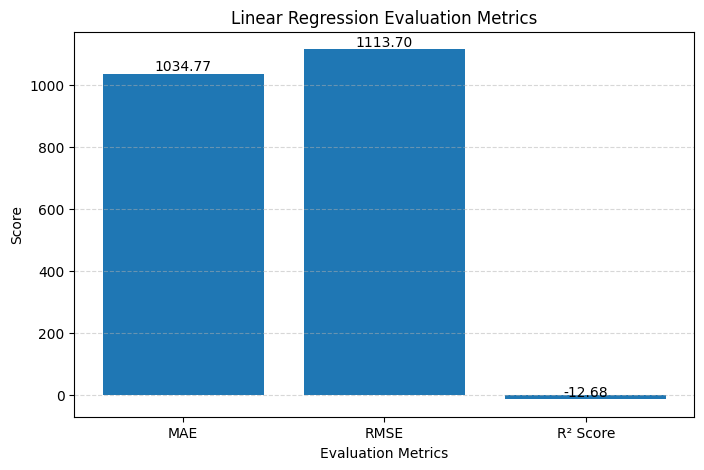

In [142]:
# Visualizing Linear Regression Evaluation Metrics

import matplotlib.pyplot as plt

metrics = ['MAE', 'RMSE', 'R² Score']
values = [mae_lr, rmse_lr, r2_lr]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values)

plt.title('Linear Regression Evaluation Metrics')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display values on bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.2f}',
        ha='center',
        va='bottom'
    )

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [143]:
# Cross-Validation for Linear Regression

from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Define time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Calculate cross-validation MAE
cv_scores = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)

# Convert negative scores into positive MAE
cv_mae_scores = -cv_scores

print("Cross-Validation MAE Scores:", cv_mae_scores)
print("Average Cross-Validation MAE:", cv_mae_scores.mean())

Cross-Validation MAE Scores: [352.22159091 217.98796421 119.98567351 204.11932234 395.49017717]
Average Cross-Validation MAE: 257.9609456284629


I used TimeSeriesSplit cross-validation with five folds because the dataset contains chronological monthly crime data.

The average cross-validation MAE was 257.96. The fold scores varied from 119.99 to 395.49, indicating differences in model performance across time periods.

Although the cross-validation error was lower than the test error, the model achieved a negative R² score on the test dataset. This indicates that Linear Regression has limited ability to capture changing crime-volume patterns over time.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

In [144]:
# ML Model 2: Random Forest Regression

from sklearn.ensemble import RandomForestRegressor

# Initialize the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Fit the model
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")
print("First 10 predictions:", y_pred_rf[:10])

Random Forest model trained successfully.
First 10 predictions: [2085.74 2192.72 2144.28 2323.17 2272.42 2191.63 2220.18 2080.35 1887.55
 1793.82]


In [145]:
# Evaluate Random Forest Regression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Evaluation:")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R² Score: {r2_rf:.4f}")

Random Forest Evaluation:
MAE: 351.85
RMSE: 432.81
R² Score: -1.0659


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

I implemented Random Forest Regression to capture nonlinear relationships in monthly crime-volume data.

The model achieved:
- MAE: 351.85
- RMSE: 432.81
- R² Score: -1.0659

Random Forest performed better than the Linear Regression baseline, reducing prediction errors. However, the negative R² score indicates that the model still requires improvement. Hyperparameter tuning will be performed to explore better performance.

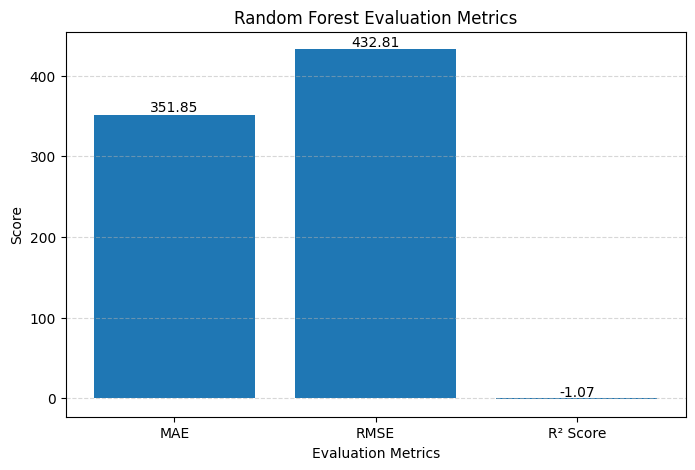

In [146]:
# Visualizing Random Forest Evaluation Metrics

import matplotlib.pyplot as plt

metrics = ['MAE', 'RMSE', 'R² Score']
values = [mae_rf, rmse_rf, r2_rf]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values)

plt.title('Random Forest Evaluation Metrics')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display values on bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.2f}',
        ha='center',
        va='bottom'
    )

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [147]:
# Random Forest Hyperparameter Tuning

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

# Define hyperparameter search space
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [1.0, 'sqrt']
}

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize Random Forest
rf_base = RandomForestRegressor(random_state=42)

# Randomized Search
rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

# Fit the search
rf_random_search.fit(X_train, y_train)

print("Best Parameters:")
print(rf_random_search.best_params_)

print("\nBest Cross-Validation MAE:")
print(-rf_random_search.best_score_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 10}

Best Cross-Validation MAE:
293.09512295093805


##### Which hyperparameter optimization technique have you used and why?

I used RandomizedSearchCV with TimeSeriesSplit for hyperparameter optimization.

RandomizedSearchCV was selected because it evaluates different combinations of hyperparameters from a defined search space, helping identify a suitable Random Forest configuration efficiently.

I used TimeSeriesSplit to preserve the chronological order of the monthly crime data and reduce the risk of future-data leakage.

The best cross-validation MAE obtained during tuning was 293.10.

In [148]:
# Evaluate Tuned Random Forest Regression

# Get the best model
best_rf_model = rf_random_search.best_estimator_

# Generate predictions
y_pred_tuned_rf = best_rf_model.predict(X_test)

# Calculate evaluation metrics
mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
rmse_tuned_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_tuned_rf)
)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print("Tuned Random Forest Evaluation:")
print(f"MAE: {mae_tuned_rf:.2f}")
print(f"RMSE: {rmse_tuned_rf:.2f}")
print(f"R² Score: {r2_tuned_rf:.4f}")

Tuned Random Forest Evaluation:
MAE: 353.28
RMSE: 437.01
R² Score: -1.1061


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

1. Mean Absolute Error (MAE):
   The Random Forest model achieved an MAE of 351.85, meaning that its monthly crime predictions were off by approximately 352 incidents on average.

   Business Impact:
   This helps law enforcement estimate the expected prediction error when planning patrol schedules, personnel, and public-safety resources.

2. Root Mean Squared Error (RMSE):
   The model achieved an RMSE of 432.81. Since RMSE gives greater importance to larger prediction errors, it helps identify whether the model makes significant forecasting mistakes.

   Business Impact:
   This can help stakeholders understand the risk of larger forecasting errors and consider additional planning buffers when allocating resources.

3. R² Score:
   The model achieved an R² score of -1.0659. The negative score indicates that Random Forest performed worse than a mean-based baseline on the testing period.

   Business Impact:
   The model should not yet be relied upon for operational resource-allocation decisions. Further improvements are required before using its predictions in practical public-safety planning.

Overall Business Impact:
Random Forest Regression reduced prediction errors compared with Linear Regression. However, its negative R² score indicates that further model improvement and validation are necessary before deployment. The model has potential to support monthly crime-volume analysis, but its predictions should be treated as exploratory until performance improves.

### ML Model - 3

In [149]:
# ML Model 3: Gradient Boosting Regression

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("First 10 Predictions:")
print(y_pred_gb[:10])

First 10 Predictions:
[2088.05020296 2249.86974659 2249.86974659 2295.88238262 2260.72634812
 2210.4269638  2185.3482466  2103.25807031 1918.71811042 1854.96884662]


In [150]:
# Evaluate Gradient Boosting Regression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Evaluation:")
print(f"MAE: {mae_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")
print(f"R² Score: {r2_gb:.4f}")

Gradient Boosting Evaluation:
MAE: 337.37
RMSE: 416.82
R² Score: -0.9161


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

I implemented Gradient Boosting Regression to capture nonlinear relationships in monthly crime data.

The model achieved:

- MAE: 337.37
- RMSE: 416.82
- R² Score: -0.9161

Gradient Boosting performed better than Linear Regression and Random Forest on the test set, achieving lower MAE and RMSE. However, the negative R² score indicates that the model performs worse than the mean baseline, so further improvement is required before operational use.

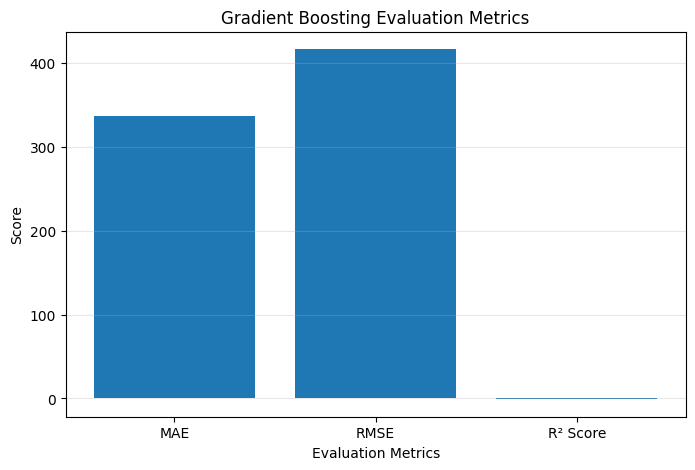

In [151]:
# Visualizing evaluation Metric Score chart

# Gradient Boosting Evaluation Metrics Chart

metrics = ['MAE', 'RMSE', 'R² Score']
values = [mae_gb, rmse_gb, r2_gb]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values)

plt.title('Gradient Boosting Evaluation Metrics')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [152]:
# Hyperparameter Tuning for Gradient Boosting

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor

param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

tscv_gb = TimeSeriesSplit(n_splits=5)

gb_base = GradientBoostingRegressor(random_state=42)

gb_random_search = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_grid_gb,
    n_iter=10,
    cv=tscv_gb,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

gb_random_search.fit(X_train, y_train)

print("Best Parameters:")
print(gb_random_search.best_params_)

print("\nBest Cross-Validation MAE:")
print(-gb_random_search.best_score_)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'learning_rate': 0.1}

Best Cross-Validation MAE:
279.84441859051134


In [153]:
# Evaluate Tuned Gradient Boosting Regression

best_gb_model = gb_random_search.best_estimator_

y_pred_tuned_gb = best_gb_model.predict(X_test)

mae_tuned_gb = mean_absolute_error(y_test, y_pred_tuned_gb)
rmse_tuned_gb = np.sqrt(mean_squared_error(y_test, y_pred_tuned_gb))
r2_tuned_gb = r2_score(y_test, y_pred_tuned_gb)

print("Tuned Gradient Boosting Evaluation:")
print(f"MAE: {mae_tuned_gb:.2f}")
print(f"RMSE: {rmse_tuned_gb:.2f}")
print(f"R² Score: {r2_tuned_gb:.4f}")

Tuned Gradient Boosting Evaluation:
MAE: 359.36
RMSE: 441.81
R² Score: -1.1527


In [154]:
import pandas as pd
import matplotlib.pyplot as plt

# Model comparison results
comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        1034.77,
        351.85,
        337.37
    ],
    'RMSE': [
        1113.70,
        432.81,
        416.82
    ],
    'R2 Score': [
        -12.6787,
        -1.0659,
        -0.9161
    ]
})

display(comparison_df)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1034.77,1113.70,-12.6787
1,Random Forest,351.85,432.81,-1.0659
2,Gradient Boosting,337.37,416.82,-0.9161


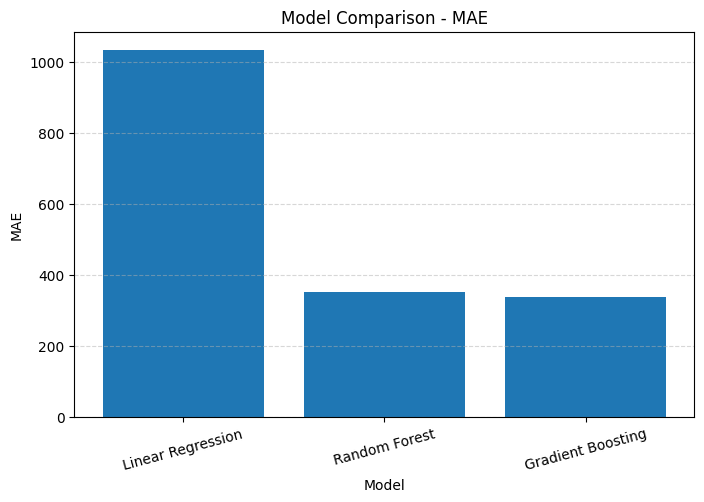

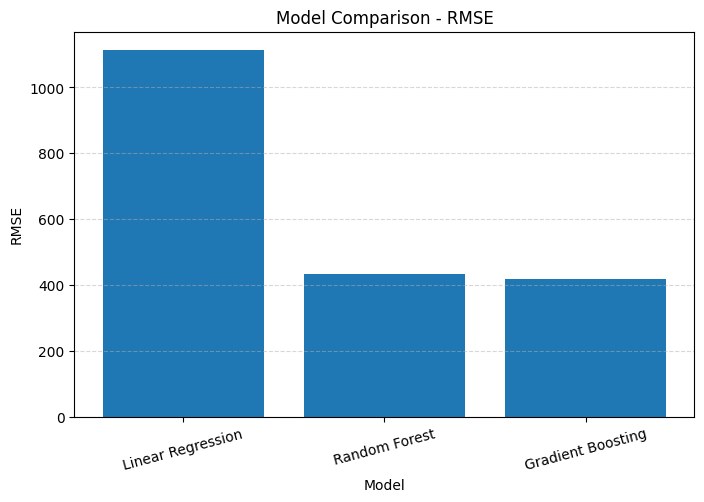

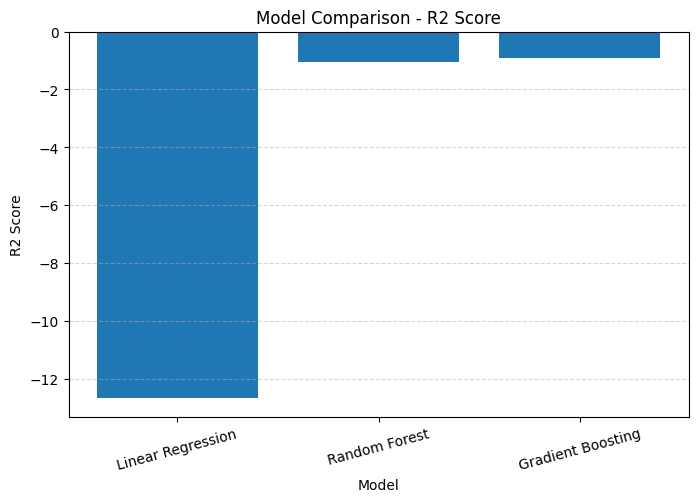

In [155]:
# Model Comparison Charts

metrics = ['MAE', 'RMSE', 'R2 Score']

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.bar(comparison_df['Model'], comparison_df[metric])
    plt.title(f'Model Comparison - {metric}')
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

### Model Comparison Interpretation

The three baseline models were compared using MAE, RMSE, and R² Score.

| Model | MAE | RMSE | R² Score |
|---|---:|---:|---:|
| Linear Regression | 1034.77 | 1113.70 | -12.6787 |
| Random Forest | 351.85 | 432.81 | -1.0659 |
| Gradient Boosting | 337.37 | 416.82 | -0.9161 |

Gradient Boosting achieved the lowest MAE and RMSE among the three baseline models. It also recorded the least negative R² Score.

However, all models produced negative R² Scores, indicating that their test performance was worse than the mean baseline. Therefore, the selected model should be treated as an experimental model and not as a reliable operational forecasting solution.

,Feature,Importance
0,YEAR,0.950839
1,MONTH,0.049161


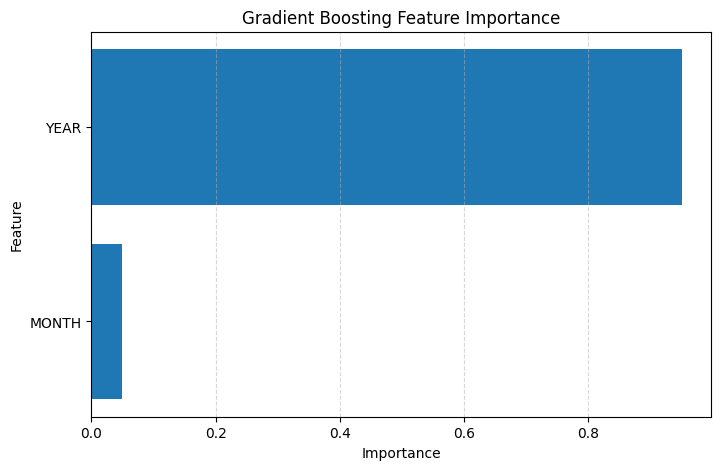

In [156]:
# Feature Importance Analysis - Gradient Boosting

import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance)

# Plot feature importance
plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Gradient Boosting Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

##### Which hyperparameter optimization technique have you used and why?

I used RandomizedSearchCV with TimeSeriesSplit cross-validation to optimize the Gradient Boosting Regressor. I selected RandomizedSearchCV because it efficiently explores different combinations of hyperparameters, while TimeSeriesSplit maintains the chronological order of the data and prevents future data from being used during training.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After hyperparameter tuning, I did not observe an improvement in the Gradient Boosting model's test performance.

| Metric | Before Tuning | After Tuning |
|---|---:|---:|
| MAE | 337.37 | 359.36 |
| RMSE | 416.82 | 441.81 |
| R² Score | -0.9161 | -1.1527 |

The tuned model performed worse than the baseline model across all three evaluation metrics. Therefore, I retained the baseline Gradient Boosting model as the better-performing version based on the test results.

## 8. Time-Series Forecasting

### Preparing Monthly Crime Data

In [157]:
# Prepare Monthly Time-Series Data

import pandas as pd
import matplotlib.pyplot as plt

# Create a monthly date column
monthly_df['Date'] = pd.to_datetime(
    monthly_df['YEAR'].astype(str) + '-' +
    monthly_df['MONTH'].astype(str) + '-01'
)

# Sort chronologically
monthly_df = monthly_df.sort_values('Date').reset_index(drop=True)

# Set Date as index
monthly_ts = monthly_df.set_index('Date')['Monthly_Crime_Count']

# Ensure monthly frequency
monthly_ts = monthly_ts.asfreq('MS')

# Display the prepared time series
display(monthly_ts.head())
display(monthly_ts.tail())

print("Total observations:", len(monthly_ts))
print("Missing values:", monthly_ts.isna().sum())

,Monthly_Crime_Count
Date,
1999-01-01,4089
1999-02-01,3296
1999-03-01,3644
1999-04-01,4002
1999-05-01,4386


,Monthly_Crime_Count
Date,
2011-08-01,2695
2011-09-01,2661
2011-10-01,2973
2011-11-01,2998
2011-12-01,2899


Total observations: 156
Missing values: 0


### Visualizing Monthly Crime Trends

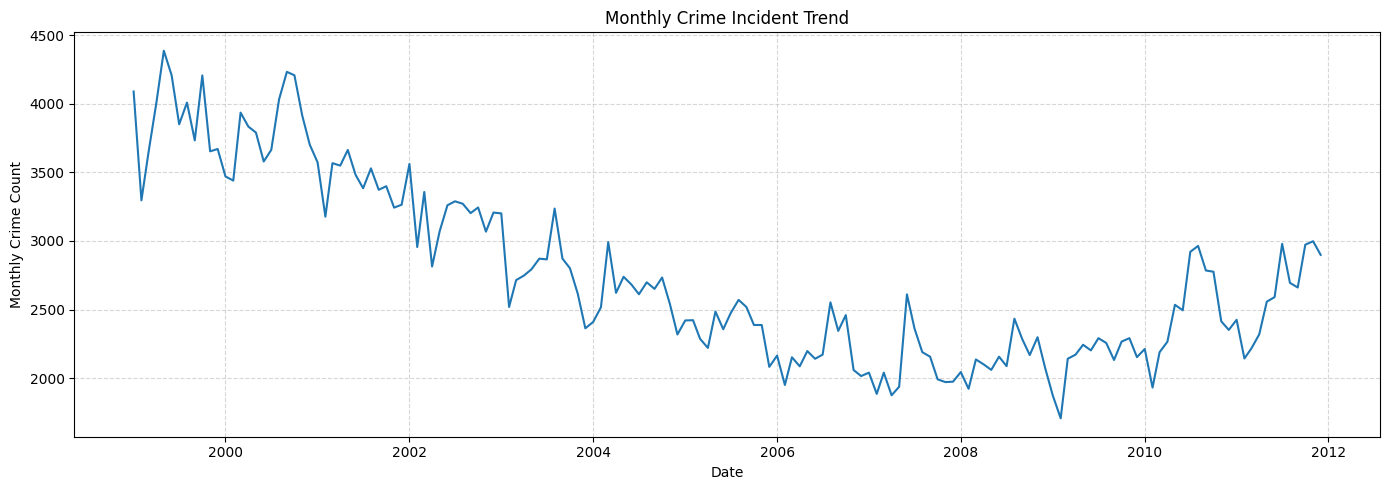

In [158]:
# Visualize Monthly Crime Trends

plt.figure(figsize=(14, 5))

plt.plot(monthly_ts.index, monthly_ts.values)

plt.title('Monthly Crime Incident Trend')
plt.xlabel('Date')
plt.ylabel('Monthly Crime Count')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Decomposing Trend and Seasonality

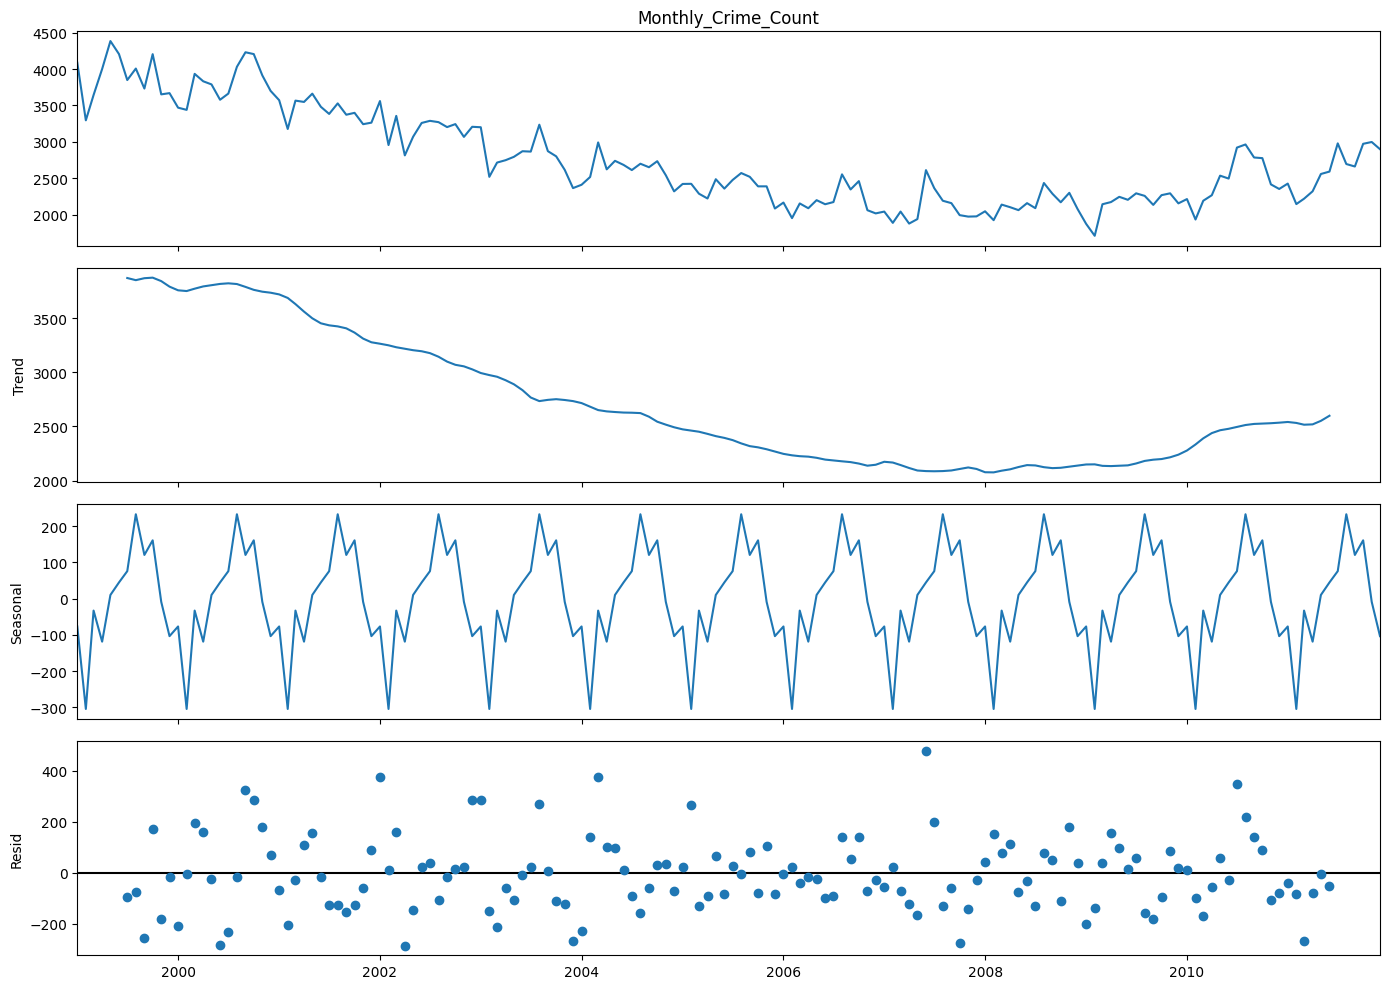

In [159]:
# Time-Series Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_ts,
    model='additive',
    period=12
)

# Display decomposition plots
fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

### Chronological Train-Test Split

In [160]:
# Chronological Train-Test Split for Time-Series Forecasting

train_size = int(len(monthly_ts) * 0.80)

ts_train = monthly_ts.iloc[:train_size]
ts_test = monthly_ts.iloc[train_size:]

print("Training observations:", len(ts_train))
print("Testing observations:", len(ts_test))

print("\nTraining period:")
print(ts_train.index.min(), "to", ts_train.index.max())

print("\nTesting period:")
print(ts_test.index.min(), "to", ts_test.index.max())

Training observations: 124
Testing observations: 32

Training period:
1999-01-01 00:00:00 to 2009-04-01 00:00:00

Testing period:
2009-05-01 00:00:00 to 2011-12-01 00:00:00


### Model 4: Seasonal Naive Forecasting

Seasonal Naive Forecasting predicts each future value using the value from the same month in the previous year.

In [161]:
# Seasonal Naive Forecasting

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Seasonal period: 12 months
seasonal_period = 12

# Use the last 12 months of training data as the seasonal pattern
last_season = ts_train.iloc[-seasonal_period:].values

# Repeat the seasonal pattern to cover the testing period
y_pred_snaive = np.tile(
    last_season,
    int(np.ceil(len(ts_test) / seasonal_period))
)[:len(ts_test)]

# Evaluate the Seasonal Naive model
mae_snaive = mean_absolute_error(ts_test, y_pred_snaive)
rmse_snaive = np.sqrt(mean_squared_error(ts_test, y_pred_snaive))
r2_snaive = r2_score(ts_test, y_pred_snaive)

print("Seasonal Naive Forecasting Results")
print("----------------------------------")
print(f"MAE: {mae_snaive:.2f}")
print(f"RMSE: {rmse_snaive:.2f}")
print(f"R² Score: {r2_snaive:.4f}")

Seasonal Naive Forecasting Results
----------------------------------
MAE: 353.88
RMSE: 437.36
R² Score: -1.1096


### Model 5: SARIMA Forecasting

SARIMA extends ARIMA by incorporating seasonal patterns. Since our data has monthly observations, we use a seasonal period of 12.

In [162]:
# SARIMA Forecasting

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define the SARIMA model
sarima_model = SARIMAX(
    ts_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Fit the model
sarima_result = sarima_model.fit(disp=False)

# Generate forecasts for the testing period
y_pred_sarima = sarima_result.forecast(steps=len(ts_test))

# Evaluate the SARIMA model
mae_sarima = mean_absolute_error(ts_test, y_pred_sarima)
rmse_sarima = np.sqrt(mean_squared_error(ts_test, y_pred_sarima))
r2_sarima = r2_score(ts_test, y_pred_sarima)

print("SARIMA Forecasting Results")
print("--------------------------")
print(f"MAE: {mae_sarima:.2f}")
print(f"RMSE: {rmse_sarima:.2f}")
print(f"R² Score: {r2_sarima:.4f}")

SARIMA Forecasting Results
--------------------------
MAE: 497.33
RMSE: 592.45
R² Score: -2.8710


### Comparison of All Five Models

In [163]:
# Compare All Five Models

comparison_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'Seasonal Naive',
        'SARIMA'
    ],
    'MAE': [
        1034.77,
        351.85,
        337.37,
        mae_snaive,
        mae_sarima
    ],
    'RMSE': [
        1113.70,
        432.81,
        416.82,
        rmse_snaive,
        rmse_sarima
    ],
    'R² Score': [
        -12.6787,
        -1.0659,
        -0.9161,
        r2_snaive,
        r2_sarima
    ]
})

display(comparison_df.round(4))

,Model,MAE,RMSE,R² Score
0,Linear Regression,1034.7700,1113.7000,-12.6787
1,Random Forest,351.8500,432.8100,-1.0659
2,Gradient Boosting,337.3700,416.8200,-0.9161
3,Seasonal Naive,353.8750,437.3612,-1.1096
4,SARIMA,497.3299,592.4533,-2.8710


### Actual vs Predicted Crime Counts

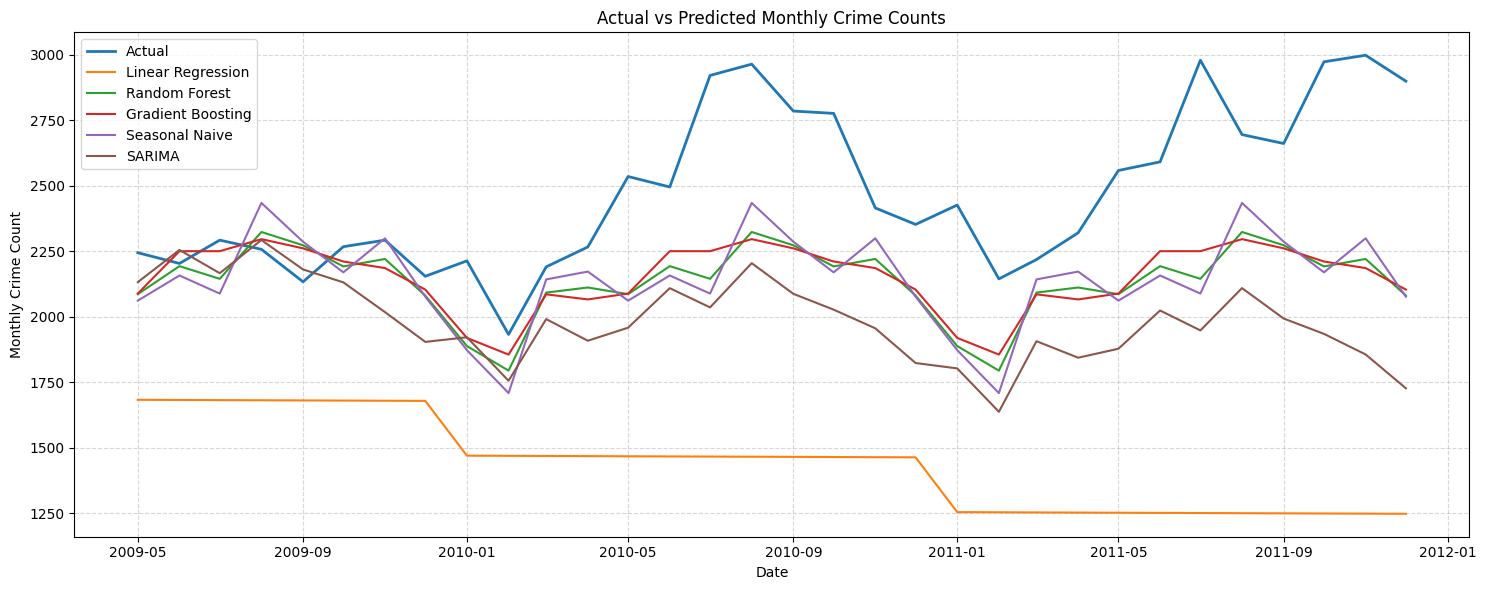

In [164]:
# Visual Comparison of Actual vs Predicted Values

plt.figure(figsize=(15, 6))

plt.plot(
    ts_test.index,
    ts_test.values,
    label='Actual',
    linewidth=2
)

plt.plot(
    ts_test.index,
    y_pred_lr,
    label='Linear Regression'
)

plt.plot(
    ts_test.index,
    y_pred_rf,
    label='Random Forest'
)

plt.plot(
    ts_test.index,
    y_pred_gb,
    label='Gradient Boosting'
)

plt.plot(
    ts_test.index,
    y_pred_snaive,
    label='Seasonal Naive'
)

plt.plot(
    ts_test.index,
    y_pred_sarima,
    label='SARIMA'
)

plt.title('Actual vs Predicted Monthly Crime Counts')
plt.xlabel('Date')
plt.ylabel('Monthly Crime Count')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Time-Series Model Comparison Interpretation

The five models were evaluated using MAE, RMSE, and R² Score on the same chronological testing period.

Gradient Boosting achieved the lowest MAE and RMSE among the five models. Seasonal Naive provided a useful seasonal baseline, while SARIMA performed worse with the selected configuration.

However, all five models produced negative R² Scores, indicating that their predictions performed worse than the mean baseline on the testing data.

The results suggest that the current models do not adequately capture the changing crime-volume patterns over time. Additional time-series features, such as lag values, rolling averages, and improved seasonal model tuning, could be explored in future work.

## 9. Advanced Time-Series Feature Engineering

We create lag features and rolling statistics to provide the models with historical crime-volume information while avoiding data leakage.

In [165]:
# Advanced Time-Series Feature Engineering

import pandas as pd
import numpy as np

# Create a working DataFrame
ts_features = monthly_ts.to_frame(name='Monthly_Crime_Count')

# Lag features
ts_features['Lag_1'] = ts_features['Monthly_Crime_Count'].shift(1)
ts_features['Lag_2'] = ts_features['Monthly_Crime_Count'].shift(2)
ts_features['Lag_3'] = ts_features['Monthly_Crime_Count'].shift(3)
ts_features['Lag_6'] = ts_features['Monthly_Crime_Count'].shift(6)
ts_features['Lag_12'] = ts_features['Monthly_Crime_Count'].shift(12)

# Rolling features
# Shift first to prevent current/future information leakage
ts_features['Rolling_Mean_3'] = (
    ts_features['Monthly_Crime_Count']
    .shift(1)
    .rolling(window=3)
    .mean()
)

ts_features['Rolling_Mean_6'] = (
    ts_features['Monthly_Crime_Count']
    .shift(1)
    .rolling(window=6)
    .mean()
)

ts_features['Rolling_Mean_12'] = (
    ts_features['Monthly_Crime_Count']
    .shift(1)
    .rolling(window=12)
    .mean()
)

# Remove rows created with missing lag values
ts_features = ts_features.dropna()

# Display results
display(ts_features.head())
display(ts_features.tail())

print("Feature dataset shape:", ts_features.shape)
print("Missing values:", ts_features.isna().sum().sum())

,Monthly_Crime_Count,Lag_1,Lag_2,Lag_3,Lag_6,Lag_12,Rolling_Mean_3,Rolling_Mean_6,Rolling_Mean_12
Date,,,,,,,,,
2000-01-01,3470,3670.0,3653.0,4206.0,3850.0,4089.0,3843.000000,3853.333333,3895.333333
2000-02-01,3440,3470.0,3670.0,3653.0,4008.0,3296.0,3597.666667,3790.000000,3843.750000
2000-03-01,3935,3440.0,3470.0,3670.0,3733.0,3644.0,3526.666667,3695.333333,3855.750000
2000-04-01,3833,3935.0,3440.0,3470.0,4206.0,4002.0,3615.000000,3729.000000,3880.000000
2000-05-01,3790,3833.0,3935.0,3440.0,3653.0,4386.0,3736.000000,3666.833333,3865.916667


,Monthly_Crime_Count,Lag_1,Lag_2,Lag_3,Lag_6,Lag_12,Rolling_Mean_3,Rolling_Mean_6,Rolling_Mean_12
Date,,,,,,,,,
2011-08-01,2695,2979.0,2591.0,2558.0,2144.0,2964.0,2709.333333,2468.333333,2544.000000
2011-09-01,2661,2695.0,2979.0,2591.0,2218.0,2785.0,2755.000000,2560.166667,2521.583333
2011-10-01,2973,2661.0,2695.0,2979.0,2320.0,2776.0,2778.333333,2634.000000,2511.250000
2011-11-01,2998,2973.0,2661.0,2695.0,2558.0,2415.0,2776.333333,2742.833333,2527.666667
2011-12-01,2899,2998.0,2973.0,2661.0,2591.0,2352.0,2877.333333,2816.166667,2576.250000


Feature dataset shape: (144, 9)
Missing values: 0


### 9.1 Chronological Train-Test Split for Feature-Engineered Models

In [166]:
# Chronological Train-Test Split

# Define features and target
X_ts = ts_features.drop(columns=['Monthly_Crime_Count'])
y_ts = ts_features['Monthly_Crime_Count']

# Use chronological 80-20 split
split_index_ts = int(len(ts_features) * 0.80)

X_ts_train = X_ts.iloc[:split_index_ts]
X_ts_test = X_ts.iloc[split_index_ts:]

y_ts_train = y_ts.iloc[:split_index_ts]
y_ts_test = y_ts.iloc[split_index_ts:]

print("Training observations:", len(X_ts_train))
print("Testing observations:", len(X_ts_test))

print("\nTraining period:")
print(X_ts_train.index.min(), "to", X_ts_train.index.max())

print("\nTesting period:")
print(X_ts_test.index.min(), "to", X_ts_test.index.max())

Training observations: 115
Testing observations: 29

Training period:
2000-01-01 00:00:00 to 2009-07-01 00:00:00

Testing period:
2009-08-01 00:00:00 to 2011-12-01 00:00:00


### 9.2 Gradient Boosting with Time-Series Features

In [167]:
# Gradient Boosting with Engineered Time-Series Features

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the model
gb_ts_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train the model
gb_ts_model.fit(X_ts_train, y_ts_train)

# Generate predictions
y_pred_gb_ts = gb_ts_model.predict(X_ts_test)

# Evaluate the model
mae_gb_ts = mean_absolute_error(y_ts_test, y_pred_gb_ts)
rmse_gb_ts = np.sqrt(mean_squared_error(y_ts_test, y_pred_gb_ts))
r2_gb_ts = r2_score(y_ts_test, y_pred_gb_ts)

print("Gradient Boosting with Time-Series Features")
print("---------------------------------------------")
print(f"MAE: {mae_gb_ts:.2f}")
print(f"RMSE: {rmse_gb_ts:.2f}")
print(f"R² Score: {r2_gb_ts:.4f}")

Gradient Boosting with Time-Series Features
---------------------------------------------
MAE: 230.40
RMSE: 304.00
R² Score: 0.0172


### 9.3 Leakage-Free Recursive Forecasting

The model generates sequential predictions using historical observations and previously predicted values without accessing future actual target values.

In [168]:
# Leakage-Free Recursive Forecasting

feature_columns = X_ts_train.columns.tolist()

# Copy the training target history
history = ts_features.loc[
    X_ts_train.index, 'Monthly_Crime_Count'
].tolist()

recursive_predictions = []

for i in range(len(X_ts_test)):

    # Create a temporary history series
    history_series = pd.Series(history)

    # Generate lag features
    input_features = {
        'Lag_1': history_series.iloc[-1],
        'Lag_2': history_series.iloc[-2],
        'Lag_3': history_series.iloc[-3],
        'Lag_6': history_series.iloc[-6],
        'Lag_12': history_series.iloc[-12],
        'Rolling_Mean_3': history_series.iloc[-3:].mean(),
        'Rolling_Mean_6': history_series.iloc[-6:].mean(),
        'Rolling_Mean_12': history_series.iloc[-12:].mean()
    }

    # Maintain the same feature order used during training
    input_df = pd.DataFrame([input_features])[feature_columns]

    # Predict the next month
    next_prediction = gb_ts_model.predict(input_df)[0]

    # Store prediction and add it to history
    recursive_predictions.append(next_prediction)
    history.append(next_prediction)

# Evaluate leakage-free predictions
mae_recursive = mean_absolute_error(
    y_ts_test, recursive_predictions
)

rmse_recursive = np.sqrt(
    mean_squared_error(y_ts_test, recursive_predictions)
)

r2_recursive = r2_score(
    y_ts_test, recursive_predictions
)

print("Leakage-Free Recursive Forecasting Results")
print("-------------------------------------------")
print(f"MAE: {mae_recursive:.2f}")
print(f"RMSE: {rmse_recursive:.2f}")
print(f"R² Score: {r2_recursive:.4f}")

Leakage-Free Recursive Forecasting Results
-------------------------------------------
MAE: 374.20
RMSE: 441.72
R² Score: -1.0749


### 9.4 Walk-Forward One-Step Forecasting

Walk-forward forecasting evaluates the model by predicting one month ahead while using previously observed actual values for subsequent predictions.

In [169]:
# Walk-Forward One-Step Forecasting

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

walk_forward_predictions = []
walk_forward_actuals = []

# Predict each test month separately
for current_date in X_ts_test.index:

    # Use only observations before the current test month
    train_mask = ts_features.index < current_date

    X_train_walk = ts_features.loc[
        train_mask, feature_columns
    ]

    y_train_walk = ts_features.loc[
        train_mask, 'Monthly_Crime_Count'
    ]

    # Current month's features
    X_current = ts_features.loc[
        [current_date], feature_columns
    ]

    y_current = ts_features.loc[
        current_date, 'Monthly_Crime_Count'
    ]

    # Create and train the model
    walk_model = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    walk_model.fit(X_train_walk, y_train_walk)

    # Predict the current month
    prediction = walk_model.predict(X_current)[0]

    walk_forward_predictions.append(prediction)
    walk_forward_actuals.append(y_current)

# Evaluate walk-forward predictions
mae_walk = mean_absolute_error(
    walk_forward_actuals,
    walk_forward_predictions
)

rmse_walk = np.sqrt(
    mean_squared_error(
        walk_forward_actuals,
        walk_forward_predictions
    )
)

r2_walk = r2_score(
    walk_forward_actuals,
    walk_forward_predictions
)

print("Walk-Forward Forecasting Results")
print("---------------------------------")
print(f"MAE: {mae_walk:.2f}")
print(f"RMSE: {rmse_walk:.2f}")
print(f"R² Score: {r2_walk:.4f}")

Walk-Forward Forecasting Results
---------------------------------
MAE: 175.34
RMSE: 230.64
R² Score: 0.4343


### 9.5 Random Forest with Time-Series Features

Random Forest Regression is evaluated using walk-forward one-step forecasting with lag and rolling features.

In [170]:
# Walk-Forward Random Forest Forecasting

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_walk_predictions = []
rf_walk_actuals = []

for current_date in X_ts_test.index:

    # Select historical data before the current month
    train_mask = ts_features.index < current_date

    X_train_walk = ts_features.loc[
        train_mask, feature_columns
    ]

    y_train_walk = ts_features.loc[
        train_mask, 'Monthly_Crime_Count'
    ]

    # Current month's features
    X_current = ts_features.loc[
        [current_date], feature_columns
    ]

    y_current = ts_features.loc[
        current_date, 'Monthly_Crime_Count'
    ]

    # Create and train Random Forest
    rf_walk_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )

    rf_walk_model.fit(X_train_walk, y_train_walk)

    # Predict one month ahead
    prediction = rf_walk_model.predict(X_current)[0]

    rf_walk_predictions.append(prediction)
    rf_walk_actuals.append(y_current)

# Evaluate the model
mae_rf_walk = mean_absolute_error(
    rf_walk_actuals,
    rf_walk_predictions
)

rmse_rf_walk = np.sqrt(
    mean_squared_error(
        rf_walk_actuals,
        rf_walk_predictions
    )
)

r2_rf_walk = r2_score(
    rf_walk_actuals,
    rf_walk_predictions
)

print("Walk-Forward Random Forest Results")
print("-----------------------------------")
print(f"MAE: {mae_rf_walk:.2f}")
print(f"RMSE: {rmse_rf_walk:.2f}")
print(f"R² Score: {r2_rf_walk:.4f}")

Walk-Forward Random Forest Results
-----------------------------------
MAE: 173.96
RMSE: 227.48
R² Score: 0.4497


### Interpretation

- Random Forest achieved an MAE of 173.96.
- The RMSE was 227.48.
- The R² score was 0.4497.
- These results represent the feature-engineered walk-forward evaluation.
- They should not be directly compared with earlier models evaluated using a different fixed holdout setup.

### 9.6 XGBoost with Time-Series Features

XGBoost Regression is evaluated using walk-forward one-step forecasting with lag and rolling features.

In [171]:
# Walk-Forward XGBoost Forecasting

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_walk_predictions = []
xgb_walk_actuals = []

for current_date in X_ts_test.index:

    # Select historical data before the current month
    train_mask = ts_features.index < current_date

    X_train_walk = ts_features.loc[
        train_mask, feature_columns
    ]

    y_train_walk = ts_features.loc[
        train_mask, 'Monthly_Crime_Count'
    ]

    # Current month's features
    X_current = ts_features.loc[
        [current_date], feature_columns
    ]

    y_current = ts_features.loc[
        current_date, 'Monthly_Crime_Count'
    ]

    # Create and train XGBoost
    xgb_walk_model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )

    xgb_walk_model.fit(X_train_walk, y_train_walk)

    # Predict one month ahead
    prediction = xgb_walk_model.predict(X_current)[0]

    xgb_walk_predictions.append(prediction)
    xgb_walk_actuals.append(y_current)

# Evaluate the model
mae_xgb_walk = mean_absolute_error(
    xgb_walk_actuals,
    xgb_walk_predictions
)

rmse_xgb_walk = np.sqrt(
    mean_squared_error(
        xgb_walk_actuals,
        xgb_walk_predictions
    )
)

r2_xgb_walk = r2_score(
    xgb_walk_actuals,
    xgb_walk_predictions
)

print("Walk-Forward XGBoost Results")
print("-----------------------------")
print(f"MAE: {mae_xgb_walk:.2f}")
print(f"RMSE: {rmse_xgb_walk:.2f}")
print(f"R² Score: {r2_xgb_walk:.4f}")

Walk-Forward XGBoost Results
-----------------------------
MAE: 165.69
RMSE: 218.64
R² Score: 0.4916


### Interpretation

- XGBoost achieved an MAE of **165.69**.
- The RMSE was **218.64**.
- The R² score was **0.4916**.
- It achieved the lowest MAE and RMSE among the three feature-engineered walk-forward models.
- It also achieved the highest R² score in this evaluation.
- These results represent one-step-ahead walk-forward forecasting performance.
- Further validation is required before considering the model for operational crime forecasting.

### Walk-Forward Validation Methodology

I evaluated the time-series models using chronological walk-forward validation instead of randomly shuffling the data.

In one-step-ahead forecasting, I used historical observations available before each prediction month to generate lag and rolling-average features. After making a prediction, the actual observed value became available and was used as historical information for the next prediction.

This approach simulates forecasting one month ahead while using updated historical data.

**Important:** These results represent one-step-ahead walk-forward forecasting performance, not long-term recursive forecasting performance.

### 9.7 Feature-Engineered Model Comparison

In [172]:
# Compare Feature-Engineered Walk-Forward Models

ts_model_comparison = pd.DataFrame({
    'Model': [
        'Gradient Boosting',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        mae_walk,
        mae_rf_walk,
        mae_xgb_walk
    ],
    'RMSE': [
        rmse_walk,
        rmse_rf_walk,
        rmse_xgb_walk
    ],
    'R² Score': [
        r2_walk,
        r2_rf_walk,
        r2_xgb_walk
    ]
})

display(ts_model_comparison.round(4))

,Model,MAE,RMSE,R² Score
0,Gradient Boosting,175.3404,230.6393,0.4343
1,Random Forest,173.9633,227.4830,0.4497
2,XGBoost,165.6864,218.6380,0.4916


### Interpretation

The comparison shows the following results:

- **Gradient Boosting:** MAE = 175.34, RMSE = 230.64, R² = 0.4343
- **Random Forest:** MAE = 173.96, RMSE = 227.48, R² = 0.4497
- **XGBoost:** MAE = 165.69, RMSE = 218.64, R² = 0.4916

XGBoost achieved the lowest MAE and RMSE and the highest R² score among the three feature-engineered walk-forward models.

These results represent **one-step-ahead walk-forward forecasting performance**, not long-term recursive forecasting performance. Therefore, further validation is required before operational deployment.

,Feature,Importance
4,Lag_12,0.4739
7,Rolling_Mean_12,0.3313
6,Rolling_Mean_6,0.0519
5,Rolling_Mean_3,0.0510
0,Lag_1,0.0474
3,Lag_6,0.0188
1,Lag_2,0.0136
2,Lag_3,0.0122


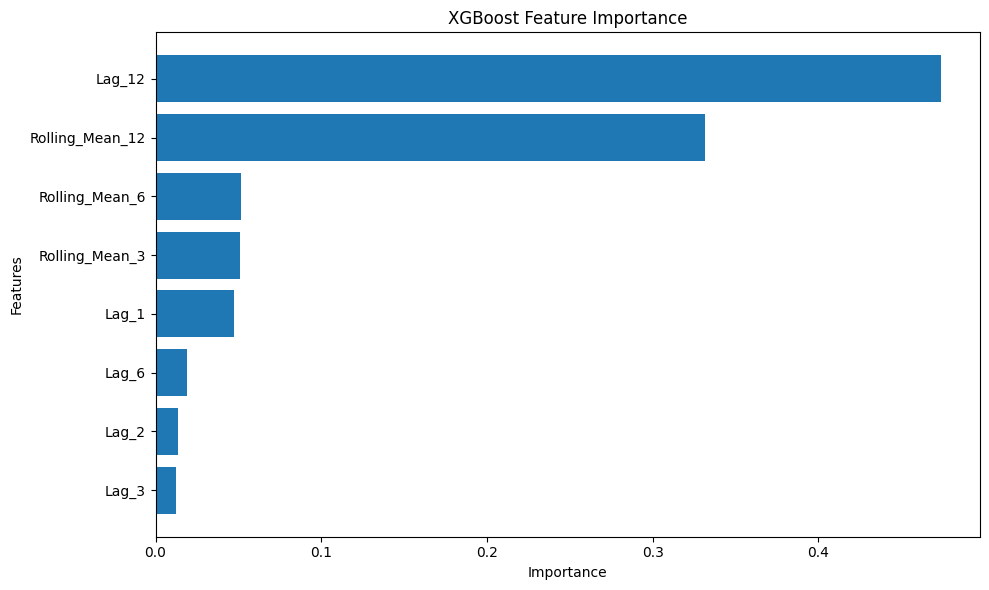

In [173]:
# XGBoost Feature Importance

from xgboost import XGBRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Train XGBoost on the training data
xgb_explain_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_explain_model.fit(X_ts_train, y_ts_train)

# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': X_ts_train.columns,
    'Importance': xgb_explain_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance.round(4))

# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

### Final Model Selection and Deployment Considerations

I selected the XGBoost Regressor as my final model because it achieved the best performance among the evaluated walk-forward models.

The model uses lag features and rolling-average features to capture historical crime patterns, including annual seasonality and longer-term trends.

The model requires historical monthly crime counts to generate the necessary features, such as Lag_1, Lag_6, Lag_12, and Rolling_Mean_12.

For Streamlit deployment, the application must use an appropriate historical dataset to generate these features before making a prediction. Entering only a year and month is not sufficient to generate all required model inputs.

The model will be deployed as an interactive forecasting application for educational and analytical purposes. Its predictions should not be treated as reliable operational crime forecasts without additional validation.

## ***10.*** ***Model Explainability***

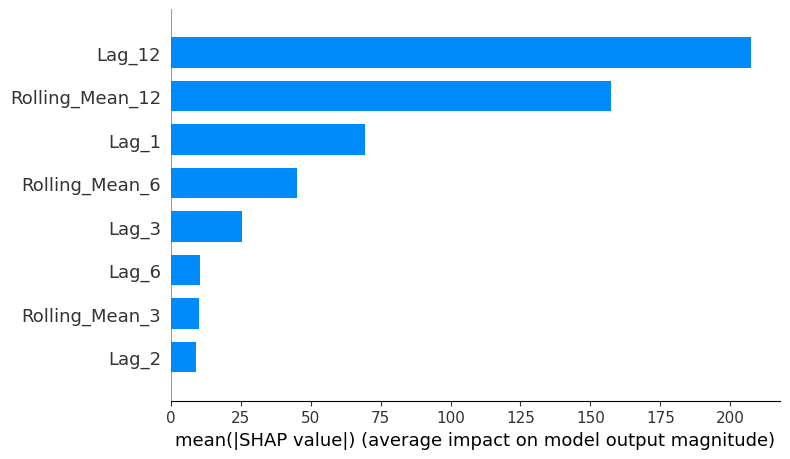

In [174]:
# Install SHAP if required
!pip install shap -q

import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_explain_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_ts_test)

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_ts_test,
    plot_type="bar"
)

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

### Answer:

I used **MAE, RMSE, and R² Score** to evaluate my monthly crime prediction models.

- **MAE:** Measures the average absolute prediction error and is easy to interpret in terms of crime incidents.
- **RMSE:** Penalizes larger prediction errors more heavily, helping identify significant forecasting mistakes.
- **R² Score:** Measures how much variation in monthly crime counts is explained by the model.

I prioritized **MAE and RMSE** because accurate crime-volume predictions can support resource planning and police department decision-making. I also used **chronological walk-forward validation** to evaluate the model using historical data without randomly shuffling the time series.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

### Answer:

I selected **XGBoost Regressor** as my final prediction model because it achieved the best evaluation results among the three feature-engineered walk-forward models.

The model achieved:

- **MAE:** 165.69
- **RMSE:** 218.64
- **R² Score:** 0.4916

I used chronological walk-forward validation, where historical observations were used to predict the next month. This evaluation measures one-step-ahead forecasting performance.

Although XGBoost performed better than the other two feature-engineered models, further validation is required before using it for operational crime forecasting.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

I used **XGBoost Regressor** for monthly crime forecasting and applied **SHAP (SHapley Additive exPlanations)** to understand feature importance.

XGBoost is a gradient-boosting algorithm that builds decision trees sequentially, with each tree improving the errors made by previous trees.

According to my SHAP analysis:

- **Lag_12:** The most influential feature, representing crime counts from 12 months earlier.
- **Rolling_Mean_12:** The second most influential feature, representing the average crime volume over the previous 12 months.
- **Rolling_Mean_6 and Lag_1:** Also contributed to the model's predictions.

The results indicate that historical annual patterns and longer-term crime trends play an important role in monthly crime predictions.

The SHAP bar plot shows the average magnitude of feature impact, but it does not indicate whether a feature increases or decreases the prediction.

## ***11.*** ***Future Work***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [175]:
import joblib
import os

# Train the final XGBoost model using all available historical data
final_xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

final_xgb_model.fit(X_ts, y_ts)

# Save the trained model
model_path = 'final_xgb_crime_forecasting_model.pkl'
joblib.dump(final_xgb_model, model_path)

print(f"Model saved successfully: {model_path}")
print(f"File exists: {os.path.exists(model_path)}")

Model saved successfully: final_xgb_crime_forecasting_model.pkl
File exists: True


In [176]:
# Save historical data required for forecasting
historical_data_path = "historical_monthly_crime_data.pkl"

joblib.dump(monthly_ts, historical_data_path)

# Save model metadata
model_metadata = {
    "feature_names": list(X_ts.columns),
    "model_name": "XGBoost Regressor",
    "forecast_frequency": "Monthly",
    "required_history_months": 12,
    "evaluation_type": "One-step-ahead walk-forward validation"
}

metadata_path = "xgb_model_metadata.pkl"

joblib.dump(model_metadata, metadata_path)

print("Model saved:", os.path.exists(model_path))
print("Historical data saved:", os.path.exists(historical_data_path))
print("Metadata saved:", os.path.exists(metadata_path))

Model saved: True
Historical data saved: True
Metadata saved: True


In [177]:
# Verify saved files by loading them

loaded_model = joblib.load(model_path)
loaded_historical_data = joblib.load(historical_data_path)
loaded_metadata = joblib.load(metadata_path)

print("Model type:", type(loaded_model))
print("Historical data shape:", loaded_historical_data.shape)
print("Feature names:", loaded_metadata["feature_names"])
print("Required history:", loaded_metadata["required_history_months"])

Model type: <class 'xgboost.sklearn.XGBRegressor'>
Historical data shape: (156,)
Feature names: ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_6', 'Lag_12', 'Rolling_Mean_3', 'Rolling_Mean_6', 'Rolling_Mean_12']
Required history: 12


In [178]:
def create_forecasting_features(history):

    features = {
        "Lag_1": history.iloc[-1],
        "Lag_2": history.iloc[-2],
        "Lag_3": history.iloc[-3],
        "Lag_6": history.iloc[-6],
        "Lag_12": history.iloc[-12],
        "Rolling_Mean_3": history.iloc[-3:].mean(),
        "Rolling_Mean_6": history.iloc[-6:].mean(),
        "Rolling_Mean_12": history.iloc[-12:].mean()
    }

    return pd.DataFrame([features])

In [179]:
# Generate features using historical data

test_features = create_forecasting_features(loaded_historical_data)

display(test_features)

print("Feature shape:", test_features.shape)
print("Feature order:", list(test_features.columns))

,Lag_1,Lag_2,Lag_3,Lag_6,Lag_12,Rolling_Mean_3,Rolling_Mean_6,Rolling_Mean_12
0,2899,2998,2973,2979,2426,2956.666667,2867.5,2621.833333


Feature shape: (1, 8)
Feature order: ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_6', 'Lag_12', 'Rolling_Mean_3', 'Rolling_Mean_6', 'Rolling_Mean_12']



I selected the **XGBoost Regressor** as my final prediction model based on its performance in one-step-ahead walk-forward validation.

I trained the final model using all available historical time-series data and saved it in **Joblib format**.

Additionally, I saved:

- **Historical monthly crime data:** Used to generate lag and rolling-average features.
- **Model metadata:** Stores feature names, forecasting frequency, and required historical months.
- **Deployment bundle:** Combines the trained model, historical data, and metadata for application deployment.

These files support the integration of the trained model into a Streamlit application for monthly crime forecasting.

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [180]:
# Load the saved model and predict using generated features

prediction = loaded_model.predict(test_features)

predicted_crime_count = max(0, round(float(prediction[0])))

print("Predicted crime count for the next month:", predicted_crime_count)

Predicted crime count for the next month: 2720


In [181]:
# Create a single deployment bundle

deployment_bundle = {
    "model": loaded_model,
    "historical_data": loaded_historical_data,
    "metadata": loaded_metadata
}

deployment_path = "crime_forecasting_deployment_bundle.pkl"

joblib.dump(deployment_bundle, deployment_path)

print("Deployment bundle saved:", os.path.exists(deployment_path))
print("Deployment file:", deployment_path)

Deployment bundle saved: True
Deployment file: crime_forecasting_deployment_bundle.pkl


In [182]:
# Verify deployment bundle

loaded_bundle = joblib.load(deployment_path)

print("Bundle keys:", loaded_bundle.keys())
print("Model loaded:", type(loaded_bundle["model"]))
print("Historical data shape:", loaded_bundle["historical_data"].shape)
print("Metadata loaded:", loaded_bundle["metadata"]["model_name"])

Bundle keys: dict_keys(['model', 'historical_data', 'metadata'])
Model loaded: <class 'xgboost.sklearn.XGBRegressor'>
Historical data shape: (156,)
Metadata loaded: XGBoost Regressor


I loaded the saved XGBoost model using Joblib and verified that it could generate predictions.

I created the required lag and rolling-average features from historical monthly crime data, ensuring that the feature names and order matched the training data.

The model successfully generated a prediction for the next month.

This verification confirmed that the trained model, historical data, and feature-generation process were compatible with the planned deployment workflow.

In [183]:
from google.colab import files

files.download("crime_forecasting_deployment_bundle.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Conclusion**

I performed data preprocessing, exploratory data analysis (EDA), hypothesis testing, and machine learning-based monthly crime prediction using the FBI Crime Investigation dataset.

I handled missing values, removed duplicate records, analyzed crime patterns across time and geography, and conducted hypothesis tests to identify differences in crime volumes.

I evaluated multiple models, including Linear Regression, Random Forest, Gradient Boosting, Seasonal Naive, SARIMA, and XGBoost. For time-series forecasting, I engineered lag and rolling-average features to capture historical crime patterns.

Among the evaluated walk-forward models, **XGBoost Regressor** achieved the following results:

- **MAE:** 165.69
- **RMSE:** 218.64
- **R² Score:** 0.4916

I used SHAP explainability to understand feature contributions. `Lag_12` and `Rolling_Mean_12` were the most influential features, indicating the importance of annual historical patterns and long-term crime trends.

### Business Impact

The analysis can help identify historical crime patterns and support data-driven resource planning. However, the model should not be treated as an operational crime forecasting system without further validation and improvement.

### Limitations and Future Improvements

- Improve forecasting accuracy through advanced time-series models.
- Include additional temporal, geographic, and external factors.
- Perform broader hyperparameter tuning and validation.
- Evaluate the model using longer forecasting horizons.
- Deploy the model through a Streamlit application for interactive predictions.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***